In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import re
import sys
import matplotlib.pyplot as plt
from functools import reduce

In [2]:
ruta = "Mexico/"
archivo = 'GRUMAB.xlsx'
ruta_archivo = ruta + archivo
archivo_stock = "Mexico/DatosHistoricos/Datos_historicos_GRUMAB_20anios"
archivo_market = "Datos históricos S&P_BMV IRT"

In [3]:
df_err = pd.read_excel(ruta_archivo, header=19)
# Filas a eliminar (ajustar índices para que sean 0-based)
filas_a_eliminar = [1, 17, 55, 88, 153, 194, 218,256]
# Eliminar las filas
df_err = df_err.drop(filas_a_eliminar)
df_err.columns = df_err.iloc[0]
if '\t' in df_err.columns:
    df = df_err.drop(columns=['\t'])
df_err = df_err[1:].reset_index(drop=True)

In [4]:
cols = df_err.columns.tolist()
ttm_idx = cols.index("TTM/current")
df_hist = df_err.iloc[:, :ttm_idx].copy() 

valid_headers = []

row = df_hist.loc[df_hist["Fiscal Period"].eq("Revenue per Share")].iloc[0]

valid_headers = [
    col for col in df_hist.columns
    if col != "Fiscal Period"
    and not pd.isna(row[col])
    and not (isinstance(row[col], str) and row[col].strip() == "-")
]

valid_years = [int(h[-4:]) for h in valid_headers]

last_20_years = valid_years[-20:]

last_20_years

[2005,
 2006,
 2007,
 2008,
 2009,
 2010,
 2011,
 2012,
 2013,
 2014,
 2015,
 2016,
 2017,
 2018,
 2019,
 2020,
 2021,
 2022,
 2023,
 2024]

In [5]:
def calcular_crecimiento_ipc(archivo_csv, anio_cierre, periodo_anos=5):
    df = pd.read_csv(f"{archivo_csv}.csv")
    df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d.%m.%Y')
    df['Cierre'] = df['Cierre'].str.replace(',', '').astype(float)
    df = df.sort_values('Fecha')
    
    # Filtrar datos del año de cierre
    df_ano = df[df['Fecha'].dt.year == anio_cierre]
    if df_ano.empty:
        raise ValueError(f"No hay datos para el año {anio_cierre}")
    fecha_final = df_ano['Fecha'].max()
    fecha_inicio = fecha_final - pd.DateOffset(years=periodo_anos)
    
    df_filtrado = df[(df['Fecha'] >= fecha_inicio) & (df['Fecha'] <= fecha_final)]
    if df_filtrado.shape[0] < 2:
        raise ValueError("Datos insuficientes para el período solicitado")
    
    precio_inicial = df_filtrado.iloc[0]['Cierre']
    precio_final = df_filtrado.iloc[-1]['Cierre']
    
    tasa = ((precio_final / precio_inicial) ** (1 / periodo_anos)) - 1
    return fecha_inicio.date(), fecha_final.date(), tasa 

# Ejemplo de uso:
archivo = "Datos históricos S&P_BMV IRT"

# años = [2023, 2022, 2021, 2020, 2019,2018, 2017, 2016, 2015, 2014,2013]

crecimiento_ipc_porcentaje_años = []

for año in last_20_years:
    fi, ff, tasa = calcular_crecimiento_ipc(archivo, año)
    crecimiento_ipc_porcentaje_años.append({
        "año_cierre": año,
        "fecha_inicio": fi,
        "fecha_final": ff,
        "CAGR_%": round(tasa, 4)
    })



In [6]:
archivo_market_cetes = "cetes_historicos"
data_cetes = pd.read_excel(archivo_market_cetes + '.xlsx' , header=17)

data_cetes['Fecha'] = pd.to_datetime(data_cetes['Fecha'], format='%d/%m/%Y')
data_cetes = data_cetes.rename(columns={data_cetes.columns[1]: 'Rendimiento'})

data_cetes = data_cetes[data_cetes['Fecha'].dt.year.isin(last_20_years)]

promedio_cetes = (
    data_cetes
    .groupby(data_cetes['Fecha'].dt.year)['Rendimiento']
    .mean()
    .reset_index()
    .rename(columns={'Fecha': 'Año', 'Rendimiento': 'Promedio_Anual'})
)
promedio_cetes['Promedio_Anual'] = promedio_cetes['Promedio_Anual'].round(4)
print(promedio_cetes)

     Año  Promedio_Anual
0   2005          9.1994
1   2006          7.4740
2   2007          7.5693
3   2008          8.0832
4   2009          5.6783
5   2010          4.8125
6   2011          4.6245
7   2012          4.5804
8   2013          3.9327
9   2014          3.2781
10  2015          3.4980
11  2016          4.6900
12  2017          7.0847
13  2018          8.0373
14  2019          7.8175
15  2020          5.2056
16  2021          5.2381
17  2022          9.2586
18  2023         11.4710
19  2024         10.8755


c:\Users\mar_c\OneDrive\Documentos\GuruFocus\guru_focus\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [7]:
archivo_inflacion_mexico = "INFLACION_mexico"
data_inflacion_mexico = pd.read_excel(archivo_inflacion_mexico + '.xlsx')

# Filtrado y extracción
resultados_inf_mexico = []
for año in last_20_years:
    fila = data_inflacion_mexico[data_inflacion_mexico['Año'] == año]
    if not fila.empty:
        tasa = fila.iloc[0]['Tasa de Inflación']/100
        resultados_inf_mexico.append({"Año": año, "Tasa de Inflación": round(tasa, 4)})
    else:
        resultados_inf_mexico.append({"Año": año, "Tasa de Inflacion": None})

# Convertir en DataFrame (o lo que prefieras)
df_resultados_inf_mexico = pd.DataFrame(resultados_inf_mexico)
print(df_resultados_inf_mexico)


     Año  Tasa de Inflación
0   2005             0.0333
1   2006             0.0405
2   2007             0.0376
3   2008             0.0653
4   2009             0.0357
5   2010             0.0440
6   2011             0.0382
7   2012             0.0357
8   2013             0.0397
9   2014             0.0408
10  2015             0.0213
11  2016             0.0336
12  2017             0.0677
13  2018             0.0483
14  2019             0.0283
15  2020             0.0315
16  2021             0.0736
17  2022             0.0782
18  2023             0.0466
19  2024             0.0421


In [8]:
# data_stock = pd.read_csv(archivo_stock + '.csv')
# data_stock['Fecha'] = pd.to_datetime(data_stock['Fecha'], format='%d.%m.%Y')
# data_stock['Cierre'] = data_stock['Cierre'].astype(str).str.replace(',', '').astype(float)
# data_stock = data_stock.dropna(subset=['Cierre'])
# # Agregar columna de año
# data_stock["Año"] = data_stock["Fecha"].dt.year

# # Filtrar solo entre 2013 y 2023
# data_filtrada = data_stock[(data_stock["Año"] >= 2013) & (data_stock["Año"] <= 2023)]

# # Calcular promedio y mediana por año
# resumen_cierre = data_filtrada.groupby("Año")["Cierre"].agg(
#     Promedio_Cierre="mean",
#     Mediana_Cierre="median"
# ).reset_index()
# resumen_cierre

In [9]:
promedio_cetes['Promedio_Anual'] = promedio_cetes['Promedio_Anual'] / 100

In [10]:

df_stock  = pd.read_csv(f"{archivo_stock}.csv")
df_market = pd.read_csv(f"{archivo_market}.csv")

# =========================
# STOCK: limpieza + rend
# =========================
df_stock['Fecha'] = pd.to_datetime(df_stock['Fecha'], format='%d.%m.%Y', errors='coerce')
df_stock = df_stock.dropna(subset=['Fecha']).sort_values('Fecha').copy()

df_stock['Cierre'] = (
    df_stock['Cierre']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.strip()
)
df_stock['Cierre'] = pd.to_numeric(df_stock['Cierre'], errors='coerce')
df_stock = df_stock.dropna(subset=['Cierre']).copy()

df_stock['Rend_Stock'] = df_stock['Cierre'].pct_change()
df_stock = df_stock.dropna(subset=['Rend_Stock']).copy()

# =========================
# MARKET: limpieza + rend
# =========================
df_market['Fecha'] = pd.to_datetime(df_market['Fecha'], format='%d.%m.%Y', errors='coerce')
df_market = df_market.dropna(subset=['Fecha']).sort_values('Fecha').copy()

df_market['Cierre'] = (
    df_market['Cierre']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.strip()
)
df_market['Cierre'] = pd.to_numeric(df_market['Cierre'], errors='coerce')
df_market = df_market.dropna(subset=['Cierre']).copy()

df_market['Rend_Market'] = df_market['Cierre'].pct_change()
df_market = df_market.dropna(subset=['Rend_Market']).copy()


In [11]:
# Asegurar datetime
df_stock['Fecha'] = pd.to_datetime(df_stock['Fecha'])
df_market['Fecha'] = pd.to_datetime(df_market['Fecha'])

# Nos quedamos solo con lo que necesitamos
df_stock_beta = df_stock[['Fecha', 'Rend_Stock']].copy()
df_market_beta = df_market[['Fecha', 'Rend_Market']].copy()

df_beta = pd.merge(
    df_stock_beta,
    df_market_beta,
    on='Fecha',
    how='inner'
).dropna()

df_beta['Año'] = df_beta['Fecha'].dt.year

def beta_anual(grupo):
    if len(grupo) < 10:   # protección: muy pocos datos
        return np.nan
    cov = grupo['Rend_Stock'].cov(grupo['Rend_Market'])
    var_m = grupo['Rend_Market'].var()
    return cov / var_m if var_m != 0 else np.nan

df_beta_resultado = (
    df_beta 
    .groupby('Año')
    .apply(beta_anual)
    .reset_index(name='Beta')
)

df_beta_resultado

C:\Users\mar_c\AppData\Local\Temp\ipykernel_24476\745892866.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(beta_anual)


,Año,Beta
0,2002,0.103550
1,2003,0.541500
2,2004,0.623591
3,2005,0.610811
4,2006,0.832320
5,2007,0.352780
6,2008,-0.012467
7,2009,1.542441
8,2010,1.194790
9,2011,0.792391


In [12]:
df_beta_20y = df_beta_resultado[df_beta_resultado['Año'].isin(last_20_years)].copy()
df_beta_20y

,Año,Beta
3,2005,0.610811
4,2006,0.832320
5,2007,0.352780
6,2008,-0.012467
7,2009,1.542441
8,2010,1.194790
9,2011,0.792391
10,2012,0.539157
11,2013,-0.185003
12,2014,0.420927


In [13]:
# Obtengo los DF para datos anulaes y trimestrales
indice_ttm = df_err.columns.get_loc('TTM/current')
# Crear una copia del DataFrame para datos anuales
df_anual = df_err.iloc[:, :indice_ttm + 1]
df_trimestral = df_err.iloc[:, indice_ttm + 1:]
df_trimestral.insert(0, 'Fiscal Period', df_err['Fiscal Period'])


In [14]:
columna_anterior = df_anual.columns[indice_ttm - 1]
anio_anterior = int(columna_anterior[-4:])
# Identificar las columnas que contienen un año en su nombre
pattern = re.compile(r'\d{4}')
columnas_con_anio = [col for col in df_anual.columns if pattern.search(col)]

# Filtrar las columnas que están dentro del rango de los últimos 20 años desde anio_anterior
anio_limite = min(last_20_years)

columnas_filtradas = [col for col in columnas_con_anio if int(
    pattern.search(col).group()) >= anio_limite]

# Asegurarse de incluir 'Fiscal Period' y 'TTM/current' si están presentes
columnas_especiales = ['Fiscal Period', 'TTM/current']
columnas_filtradas = [
    col for col in df_anual.columns if col in columnas_especiales] + columnas_filtradas

# Crear un nuevo DataFrame con las columnas filtradas
df_anual_filtrado = df_anual[columnas_filtradas]

# Mover la columna 'TTM/current' al final
if 'TTM/current' in df_anual_filtrado.columns:
    columnas_ordenadas = [
        col for col in df_anual_filtrado.columns if col != 'TTM/current'] + ['TTM/current']
    df_anual_filtrado = df_anual_filtrado[columnas_ordenadas]

df_anual_filtrado = df_anual_filtrado.fillna(0)


In [15]:
df_anual_filtrado

,Fiscal Period,Dec2005,Dec2006,Dec2007,Dec2008,Dec2009,Dec2010,Dec2011,Dec2012,Dec2013,...,Dec2016,Dec2017,Dec2018,Dec2019,Dec2020,Dec2021,Dec2022,Dec2023,Dec2024,TTM/current
0,Revenue per Share,60.081,62.346,73.76,77.344,88.057,82.413,85.112,88.377,110.833,...,155.944,159.249,176.278,186.76,225.925,247.529,293.863,305.651,360.6,347.137
1,EBITDA per Share,6.023,6.07,6.287,-15.799,11.017,7.854,15.654,7.441,14.3,...,25.695,24.497,27.428,30.75,34.345,35.75,37.984,40.522,59.568,64.549
2,EBIT per Share,3.522,3.625,3.859,-18.234,8.142,5.175,13.089,4.71,10.753,...,21.354,19.965,21.922,23.077,25.185,26.148,27.663,30.109,46.179,51.196
3,Earnings per Share (Diluted),2.66,3.254,4.601,-21.301,2.664,0.774,9.251,2.004,7.15,...,13.535,14.031,11.831,11.67,13.313,16.113,16.673,19.944,29.582,30.04
4,EPS without NRI,2.545,3.709,2.612,-3.23,2.354,1.023,1.811,0.783,7.511,...,11.683,15.511,12.096,11.798,13.827,14.878,17.019,19.99,29.116,30.039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
252,Profitability Rank,0,0,0,0,0,0,0,0,0,...,7,6,6,6,8,8,9,8,9,9
253,GF Value Rank,0,0,0,0,0,0,0,0,0,...,0,4,10,8,8,9,9,5,7,10
254,Growth Rank,0,0,0,0,0,0,0,0,0,...,0,7,7,7,10,4,4,5,9,6
255,Momentum Rank,0,0,0,0,0,0,0,0,0,...,0,7,8,7,8,7,7,9,7,4


In [16]:
pattern = re.compile(r"\d{4}")

columnas_con_anio_trimestral = [
    col for col in df_trimestral.columns
    if col != "Fiscal Period" and pattern.search(str(col))
]

anio_min = min(last_20_years)
anio_max = max(last_20_years)

columnas_filtradas_trimestral = [
    col for col in columnas_con_anio_trimestral
    if anio_min <= int(pattern.search(str(col)).group()) <= anio_max
]

# (Opcional) ordenar por año para que queden en secuencia
columnas_filtradas_trimestral.sort(key=lambda c: int(pattern.search(str(c)).group()))

columnas_especiales_trimestral = ["Fiscal Period"]

df_trimestral_filtrado = df_trimestral[columnas_especiales_trimestral + columnas_filtradas_trimestral].copy()
df_trimestral_filtrado = df_trimestral_filtrado.fillna(0)

In [17]:
df_anual_filtrado = df_anual_filtrado.drop(columns=["TTM/current"])

In [18]:
def limpiar_df_financiero(df):
    df = df.copy()

    # Reemplazar '-' por NaN en todo el DF
    df.replace('-', np.nan, inplace=True)

    # Todas las columnas excepto 'Fiscal Period' a numéricas
    cols_datos = df.columns.drop('Fiscal Period')

    df[cols_datos] = df[cols_datos].apply(
        pd.to_numeric, errors='coerce'
    )

    return df

df_anual_filtrado = limpiar_df_financiero(df_anual_filtrado)
df_trimestral_filtrado = limpiar_df_financiero(df_trimestral_filtrado)

C:\Users\mar_c\AppData\Local\Temp\ipykernel_24476\1578466456.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace('-', np.nan, inplace=True)


In [19]:
df_anual_filtrado = df_anual_filtrado.dropna(axis=1, how='all')
df_trimestral_filtrado = df_trimestral_filtrado.dropna(axis=1, how='all')

In [20]:
# Crear DataFrame vacío con las columnas anuales
razones_financieras = pd.DataFrame(
    columns=df_anual_filtrado.columns.difference(['Fiscal Period']))


def agregar_razon_financiera(df_anual_filtrado, fila_numerador, nombre_nueva_fila, *filas_denominadoras, como_porcentaje=True):

    global razones_financieras

    # Obtener la fila numerador
    fila_num = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == fila_numerador].iloc[0, 1:]

    # Obtener y sumar las filas denominadoras
    fila_den = sum(df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == fila].iloc[0, 1:].values for fila in filas_denominadoras)

    # Calcular la razón financiera, manejando la división por cero
    razon_financiera = []
    for num, den in zip(fila_num.values, fila_den):
        if den != 0:
            razon = num / den
            if como_porcentaje:
                razon *= 100
            razon_financiera.append(f"{razon:.2f}")
        else:
            razon_financiera.append("no deuda")

    # Agregar el resultado al DataFrame
    razones_financieras.loc[nombre_nueva_fila] = razon_financiera

def agregar_razon_financiera_numerador(df_anual_filtrado, nombre_nueva_fila, fila_denominador, fila_numerador_1, fila_numerador_2, como_porcentaje=True):

    global razones_financieras

    # Obtener las filas numeradoras
    fila_num_1 = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == fila_numerador_1].iloc[0, 1:]
    fila_num_2 = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == fila_numerador_2].iloc[0, 1:]

    # Obtener la fila denominador
    fila_den = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == fila_denominador].iloc[0, 1:]

    # Restar las filas numeradoras
    resta_numeradores = fila_num_1.values - fila_num_2.values

    # Calcular la razón financiera, manejando la división por cero
    razon_financiera = []
    for num, den in zip(resta_numeradores, fila_den.values):
        if den != 0:
            razon = num / den
            if como_porcentaje:
                razon *= 100
            razon_financiera.append(f"{razon:.2f}")
        else:
            razon_financiera.append("no deuda")

    # Agregar el resultado al DataFrame razones_financieras
    razones_financieras.loc[nombre_nueva_fila] = razon_financiera

def agregar_fila(df_anual_filtrado, fila_nombre, nombre_nueva_fila):

    global razones_financieras

    # Obtener la fila relevante
    fila = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == fila_nombre].iloc[0, 1:]

    # Agregar el resultado al DataFrame
    razones_financieras.loc[nombre_nueva_fila] = fila.values

def agregar_crecimiento_anual(fila_nombre, nombre_nueva_fila):

    global razones_financieras

    # Obtener la fila relevante
    fila = razones_financieras.loc[fila_nombre].astype(float)

    # Calcular el crecimiento año a año (YoY)
    crecimiento_anual = fila.pct_change() * 100

    # Reemplazar NaN por 0
    crecimiento_anual = crecimiento_anual.fillna(0)

    # Formatear el resultado a dos decimales
    crecimiento_anual_formateado = [f"{x:.2f}" for x in crecimiento_anual]

    # Agregar el resultado al DataFrame
    razones_financieras.loc[nombre_nueva_fila] = crecimiento_anual_formateado

def dividir_filas_razones_financieras(fila_numerador, fila_denominador, nombre_nueva_fila, como_porcentaje=True):
    global razones_financieras

    # Obtener las filas relevantes para el cálculo
    fila_num = razones_financieras.loc[fila_numerador].astype(float)
    fila_den = razones_financieras.loc[fila_denominador].astype(float)

    # Calcular la razón financiera
    razon_financiera = fila_num.values / fila_den.values

    # Convertir a porcentaje si es necesario
    if como_porcentaje:
        razon_financiera *= 100

    # Reemplazar NaN por 0
    razon_financiera = pd.Series(razon_financiera).fillna(0).values

    # Formatear el resultado a dos decimales
    razon_financiera_formateada = [f"{x:.2f}" for x in razon_financiera]

    # Agregar el resultado al DataFrame
    razones_financieras.loc[nombre_nueva_fila] = razon_financiera_formateada



In [21]:
# Llamadas a la función con el nuevo orden de parámetros
agregar_razon_financiera(df_anual_filtrado, 'Depreciation, Depletion and Amortization', 'Amortizacion(%)', 'Gross Profit', como_porcentaje=True)
agregar_razon_financiera(df_anual_filtrado, 'Net Income', 'Beneficio Neto(%)', 'Revenue', como_porcentaje=True)
agregar_fila(df_anual_filtrado, 'Net Income', 'Beneficio Neto')
agregar_razon_financiera(df_anual_filtrado, 'Gross Profit', 'Margen Bruto(%)', 'Revenue', como_porcentaje=True)
agregar_razon_financiera(df_anual_filtrado, 'Operating Income', 'Margen Operativo(%)', 'Revenue', como_porcentaje=True)
agregar_razon_financiera(df_anual_filtrado, 'Net Income', 'EPS', 'Shares Outstanding (Diluted Average)', como_porcentaje=False)
agregar_razon_financiera(df_anual_filtrado, 'Revenue', 'Revenue Per Share', 'Shares Outstanding (Diluted Average)', como_porcentaje=False)
agregar_fila(df_anual_filtrado, 'Shares Outstanding (Diluted Average)', '# de Acciones')
agregar_fila(df_anual_filtrado, 'Revenue', 'Ventas')
agregar_crecimiento_anual('Beneficio Neto', 'Crecimiento Beneficio Neto')
agregar_crecimiento_anual('Ventas', 'Crecimiento Ventas')
agregar_fila(df_anual_filtrado, 'Cost of Goods Sold', 'Costo de Ventas')
agregar_crecimiento_anual('Costo de Ventas', 'Crecimiento Costo de Ventas')
agregar_fila(df_anual_filtrado, 'Total Inventories', 'Inventarios')
agregar_crecimiento_anual('Inventarios', 'Crecimiento Inventarios')
agregar_razon_financiera(df_anual_filtrado, '  Accounts Receivable', 'Cuentas por cobrar/ventas', 'Revenue', como_porcentaje=True)
agregar_fila(df_anual_filtrado, 'Dividends per Share', 'Dividendos por Accion')
agregar_fila(df_anual_filtrado, 'Free Cash Flow', 'Flujo de Caja Libre')
dividir_filas_razones_financieras('Flujo de Caja Libre', 'Ventas', 'FCF/ventas',True)
dividir_filas_razones_financieras('Flujo de Caja Libre','# de Acciones','Free cash flow per share',True)
agregar_razon_financiera(df_anual_filtrado,'Free Cash Flow','FCF/DEBT','Short-Term Debt & Capital Lease Obligation','Long-Term Debt & Capital Lease Obligation',como_porcentaje=False)
agregar_razon_financiera(df_anual_filtrado,'Free Cash Flow','FCF/DEBT corto plazo','Short-Term Debt & Capital Lease Obligation',como_porcentaje=False)
dividir_filas_razones_financieras('Dividendos por Accion',"EPS",'Dividend Payout Ratio',True)
agregar_razon_financiera(df_anual_filtrado,'Net Income','Net Income vs Deuda Largo Plazo','Long-Term Debt & Capital Lease Obligation',como_porcentaje=False)
agregar_razon_financiera(df_anual_filtrado,'Total Liabilities','Pasivo/Fondos Propios','Total Equity',como_porcentaje=False)
agregar_razon_financiera(df_anual_filtrado,'Total Current Assets','Ratio de Solvencia','Total Current Liabilities',como_porcentaje=False)
agregar_razon_financiera(df_anual_filtrado,'Long-Term Debt & Capital Lease Obligation','Deuda/Capital','Total Equity',como_porcentaje=False)
agregar_razon_financiera(df_anual_filtrado,'  Interest Expense','Gasto financiero','Operating Income',como_porcentaje=True) ##Interes Expense viene negativo, tenerlo en cuenta ya que si queda positivo seria malo ya que el operating income es tambien negativo
agregar_razon_financiera(df_anual_filtrado,'Total Inventories','Inventory to current Assetis','Total Current Assets',como_porcentaje=True)
agregar_fila(df_anual_filtrado,'Cash Conversion Cycle','Net Trading Cycle')
agregar_fila(df_anual_filtrado,'PEG Ratio','PEGY Ratio')
agregar_fila(df_anual_filtrado,'PE Ratio','PER')
agregar_fila(df_anual_filtrado,'PS Ratio','P/S Ratio')
agregar_razon_financiera(df_anual_filtrado,'  Accounts Receivable','Receivable to Current Assets','Total Current Assets',como_porcentaje=True)
agregar_fila(df_anual_filtrado,'ROA %','ROA%')
agregar_fila(df_anual_filtrado,'ROE %','ROE%')
agregar_razon_financiera(df_anual_filtrado,'Total Assets','ROB','Total Equity',como_porcentaje=False)
agregar_fila(df_anual_filtrado,'ROIC %','ROIC %')
agregar_fila(df_anual_filtrado,'WACC %','WACC %')
agregar_razon_financiera_numerador(df_anual_filtrado,'Test de Acidez','Total Current Liabilities','Total Current Assets','Total Inventories',como_porcentaje=False)
agregar_fila(df_anual_filtrado,'Book Value per Share','Valor en libros')
agregar_fila(df_anual_filtrado,'Piotroski F-Score','Piotrivski F-Score')
agregar_fila(df_anual_filtrado,'Altman Z-Score','Altman Z score')
agregar_fila(df_anual_filtrado,'Beneish M-Score','Beneish M-Score')
agregar_fila(df_anual_filtrado,'Dividends per Share','Dividendo por accion')
agregar_crecimiento_anual('Dividendo por accion','Crecimiento Dividendo por accion')
razones_financieras

,Dec2005,Dec2006,Dec2007,Dec2008,Dec2009,Dec2010,Dec2011,Dec2012,Dec2013,Dec2014,Dec2015,Dec2016,Dec2017,Dec2018,Dec2019,Dec2020,Dec2021,Dec2022,Dec2023,Dec2024
Amortizacion(%),12.00,11.26,10.14,9.69,9.48,10.24,9.67,9.69,9.36,7.95,7.15,7.29,7.50,8.35,11.07,10.60,10.78,9.93,9.60,9.64
Beneficio Neto(%),4.45,4.97,6.24,-27.55,3.03,0.93,10.87,2.26,6.45,8.59,1.31,8.68,8.81,6.71,6.25,5.89,6.54,5.70,6.53,8.20
Beneficio Neto,1241.038,1531.953,2219.413,-12035.397,1503.0,433.83,5214.843,1117.758,3158.908,4225.712,752.974,5859.389,6071.337,5082.039,4877.378,5385.456,6322.896,6261.476,7383.439,10776.922
Margen Bruto(%),34.69,34.84,32.45,32.50,34.44,31.73,31.18,31.91,34.20,36.77,38.33,38.20,37.94,37.40,37.11,38.25,35.97,35.37,35.49,38.52
Margen Operativo(%),5.86,5.81,5.23,7.29,7.54,4.57,5.35,5.34,9.75,12.55,13.46,12.98,12.92,12.68,11.94,12.45,11.12,11.13,12.35,13.56
EPS,2.67,3.10,4.60,-21.31,2.67,0.77,9.25,2.00,7.15,9.76,1.74,13.54,14.03,11.83,11.67,13.31,16.18,16.76,19.96,29.57
Revenue Per Share,60.08,62.35,73.76,77.34,88.06,82.41,85.11,88.38,110.83,113.73,133.11,155.94,159.25,176.28,186.76,225.93,247.53,293.86,305.65,360.60
# de Acciones,464.611,494.005,482.55,564.853,563.651,563.651,563.651,558.712,441.835,432.749,432.749,432.749,432.749,429.49,417.944,404.552,390.875,373.564,369.909,364.492
Ventas,27914.272,30799.309,35592.936,43687.74,49633.159,46452.148,47973.736,49377.232,48969.992,49217.903,57603.533,67484.658,68914.837,75709.77,78055.176,91398.472,96752.847,109776.602,113063.149,131435.824
Crecimiento Beneficio Neto,0.00,23.44,44.87,-642.28,-112.49,-71.14,1102.05,-78.57,182.61,33.77,-82.18,678.17,3.62,-16.29,-4.03,10.42,17.41,-0.97,17.92,45.96


In [22]:
razones_financieras.loc["Beneish M-Score"] = razones_financieras.loc["Beneish M-Score"].astype(float).abs()
razones_financieras.loc["Gasto financiero"] = razones_financieras.loc["Gasto financiero"].astype(float).abs()

In [23]:
# Convertir los valores a numéricos, convirtiendo los no numéricos a NaN
razones_financieras_numeric = razones_financieras.apply(pd.to_numeric, errors='coerce')

# Ignorar las columnas que contienen "2020" o "2021" para las filas específicas
filas_a_ignorar = ["Crecimiento Beneficio Neto", "Crecimiento Costo de Ventas", "Crecimiento Inventarios", "Crecimiento Ventas", "Crecimiento Dividendo por accion"]

# Crear una copia del DataFrame para modificar
razones_financieras_modificado = razones_financieras_numeric.copy()

# Establecer los valores de las columnas a ignorar en NaN para las filas específicas
for fila in filas_a_ignorar:
    for col in razones_financieras_modificado.columns:
        if '2020' in col or '2021' in col:
            razones_financieras_modificado.loc[fila, col] = np.nan

# Calcular el promedio de cada fila, ignorando los NaN y valores no finitos
promedios = razones_financieras_modificado.apply(lambda row: np.nanmean(row[np.isfinite(row)]), axis=1)

# Redondear los valores a dos decimales
promedios_redondeados = promedios.round(2)

# Convertir los promedios a un DataFrame
promedios_df = promedios_redondeados.to_frame(name='Promedio')
promedios_df

,Promedio
Amortizacion(%),9.57
Beneficio Neto(%),4.24
Beneficio Neto,3369.22
Margen Bruto(%),35.36
Margen Operativo(%),9.69
EPS,8.46
Revenue Per Share,154.35
# de Acciones,458.97
Ventas,65990.66
Crecimiento Beneficio Neto,62.47


## Book Value per Share

In [24]:
total_assets = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Total Assets'].iloc[0, 1:]
total_liabilities = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Total Liabilities'].iloc[0, 1:]
total_shares = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Shares Outstanding (Basic Average)'].iloc[0, 1:]

In [25]:
# Calcular el valor en libros (Book Value) para cada año
book_value = total_assets - total_liabilities

# Calcular el valor en libros por acción (Book Value per Share) para cada año
book_value_per_share = book_value / total_shares

# Crear un DataFrame para almacenar los resultados
book_value_per_share_anual = pd.DataFrame({
    'Book Value': book_value,
    'Book Value per Share': book_value_per_share
}, index=total_assets.index)

book_value_per_share_anual

,Book Value,Book Value per Share
0,,
Dec2005,14752.101,31.75151
Dec2006,17128.852,34.673439
Dec2007,18461.466,38.26163
Dec2008,9052.61,16.026488
Dec2009,11611.338,20.600226
Dec2010,10670.997,18.931922
Dec2011,17524.873,31.091709
Dec2012,14364.746,25.710466
Dec2013,14407.579,32.608505


## Liquidation Value


Utilizable con empresas a la baja, si el precio se encuentra por debajo de este,podria ser una oportunidad

1️⃣ Ratio de Recuperación del Efectivo (
𝑅
𝐸
R 
E
​
 )
(Normalmente 100%)
Se incluyen todas las cuentas que representan efectivo o equivalentes de efectivo, que son altamente líquidos.

Cuentas relevantes:

Cash And Cash Equivalents
Marketable Securities
Cash, Cash Equivalents, Marketable Securities (si está consolidado)
2️⃣ Ratio de Recuperación de Cuentas por Cobrar (
𝑅
𝐶
R 
C
​
 )
(Usualmente entre 70-90%)
Se incluyen todas las cuentas por cobrar, notas por cobrar y otros montos adeudados a la empresa.

Cuentas relevantes:

Accounts Receivable
Notes Receivable
Loans Receivable
Other Current Receivables
Total Receivables (si está consolidado)
3️⃣ Ratio de Recuperación de Inventarios (
𝑅
𝐼
R 
I
​
 )
(Suele ser 50-80%)
Incluye todos los bienes en inventario que la empresa posee, como materia prima, productos en proceso y productos terminados.

Cuentas relevantes:

Inventories, Raw Materials & Components
Inventories, Work In Process
Inventories, Finished Goods
Inventories, Other
Total Inventories (si está consolidado)
4️⃣ Ratio de Recuperación de Propiedades, Planta y Equipos (
𝑅
𝑃
R 
P
​
 )
(Usualmente 60-90%)
Incluye activos fijos tangibles como edificios, maquinaria y terrenos.

Cuentas relevantes:

Land And Improvements
Buildings And Improvements
Machinery, Furniture, Equipment
Construction In Progress
Other Gross PPE
Gross Property, Plant and Equipment
Property, Plant and Equipment (si está consolidado)
⚠️ Acumulated Depreciation → Se resta porque representa la pérdida de valor de los activos.
5️⃣ Ratio de Recuperación de Otros Activos Tangibles (
𝑅
𝑂
R 
O
​
 )
(Depende del tipo de activo, entre 10-80%)
Incluye otros activos físicos que no encajan en las categorías anteriores, como infraestructura, vehículos y mobiliario.

Cuentas relevantes:

Investments And Advances (si contiene activos tangibles)
Other Long Term Assets (si son tangibles)
Otros activos que no sean intangibles o Goodwill
⚠️ No se incluyen:

Intangible Assets (valor de marca, patentes, etc.)
Goodwill (ya que en liquidación normalmente no tiene valor)

In [26]:
ratio_recuperacion_efectivo = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Cash, Cash Equivalents, Marketable Securities'].iloc[0, 1:] * 0.95

ratio_recuperacion_cc = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Total Receivables'].iloc[0, 1:] * 0.75

ratio_recuperacion_inv = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Total Inventories'].iloc[0, 1:] * 0.60

ratio_recuperacion_ppe = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Property, Plant and Equipment'].iloc[0, 1:] * 0.70

ratio_recuperacion_act_tangibles =df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Investments And Advances'].iloc[0, 1:] + df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Other Long Term Assets'].iloc[0, 1:] *.30

total_liabilities = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Total Liabilities'].iloc[0, 1:]


In [27]:
liquidation_value = ratio_recuperacion_efectivo + ratio_recuperacion_cc + ratio_recuperacion_inv + ratio_recuperacion_ppe + ratio_recuperacion_act_tangibles - total_liabilities

liquidation_value_per_share = liquidation_value / total_shares

liquidation_value_per_share

0
Dec2005     7.031579
Dec2006      9.58029
Dec2007    10.104073
Dec2008   -15.322869
Dec2009   -10.554569
Dec2010   -11.661502
Dec2011     0.848849
Dec2012    -10.60622
Dec2013    -9.032459
Dec2014      2.80837
Dec2015     2.274641
Dec2016     9.241771
Dec2017     4.154314
Dec2018     4.392508
Dec2019    -0.174469
Dec2020     2.997834
Dec2021     0.320679
Dec2022    -7.606452
Dec2023     7.000518
Dec2024    17.651059
dtype: object

## EPV

In [28]:
# Extraer la serie del margen operativo
margen_operativo = razones_financieras.loc["Margen Operativo(%)"].copy()

# Convertir índice a años numéricos
margen_operativo.index = margen_operativo.index.str.extract(r'(\d{4})').astype(int)[0]

# Convertir a DataFrame y valores numéricos
df_margen = margen_operativo.to_frame(name="Margen_Operativo")
df_margen["Margen_Operativo"] = pd.to_numeric(df_margen["Margen_Operativo"], errors="coerce")

# Asegurar índice correcto
df_margen = df_margen.sort_index()
df_margen.index = df_margen.index.astype(int)

# Promedio móvil de 5 años hacia atrás (excluye año actual)
serie_promedios = (
    df_margen["Margen_Operativo"]
        .shift(1)                          # excluye el año actual
        .rolling(window=5, min_periods=1)
        .mean()
)


# Convertir a DataFrame con el mismo formato original
df_promedios_ebit = (
    serie_promedios
        .round(2)
        .div(100)                          # convertir a decimal
        .to_frame(name="Promedio_Margen_Operativo")
        .reset_index()
        .rename(columns={"index": "Año"})
)

df_promedios_ebit

,0,Promedio_Margen_Operativo
0,2005,NaN
1,2006,0.0586
2,2007,0.0584
3,2008,0.0563
4,2009,0.0605
5,2010,0.0635
6,2011,0.0609
7,2012,0.0600
8,2013,0.0602
9,2014,0.0651


In [29]:
# Extraer la serie de ventas
ventas = razones_financieras.loc["Ventas"].copy()

# Convertir índice a años numéricos
ventas.index = ventas.index.str.extract(r'(\d{4})').astype(int)[0]

# Convertir a DataFrame y a valores numéricos
df_ventas = ventas.to_frame(name="Ventas")
df_ventas["Ventas"] = pd.to_numeric(df_ventas["Ventas"], errors="coerce")

# Asegurar índice correcto
df_ventas = df_ventas.sort_index()
df_ventas.index = df_ventas.index.astype(int)

# Promedio móvil de 5 años hacia atrás (excluye año actual)
serie_promedios = (
    df_ventas["Ventas"]
        .shift(1)                          # excluye el año actual
        .rolling(window=5, min_periods=1)
        .mean()
)


# Crear DataFrame final (mismos nombres que el original)
df_promedios_ventas = (
    serie_promedios
        .round(2)
        .to_frame(name="Promedio_Ventas")
        .reset_index()
        .rename(columns={"index": "Año"})
)

df_promedios_ventas


,0,Promedio_Ventas
0,2005,NaN
1,2006,27914.27
2,2007,29356.79
3,2008,31435.51
4,2009,34498.56
5,2010,37525.48
6,2011,41233.06
7,2012,44667.94
8,2013,47424.80
9,2014,48481.25


In [30]:

SGyA = df_trimestral_filtrado[df_trimestral_filtrado['Fiscal Period'] == 'Selling, General, & Admin. Expense'].iloc[0, 1:]
# Convertir índices trimestrales a fechas
SGyA.index = pd.to_datetime(SGyA.index, format="%b%Y")

# Crear DataFrame a partir de la Serie
df_sgya = SGyA.astype(str).str.replace(",", "").astype(float).to_frame(name="SGyA")

# Crear una columna con el año
df_sgya["Año"] = df_sgya.index.year
anios_completos = (
    df_sgya.groupby("Año")
           .size()
           .loc[lambda s: s >= 4]
           .index
           .tolist()
)

ultimos_20_anios = sorted(anios_completos)[-20:]
# Calcular el promedio de los últimos 20 trimestres antes de cada año de cierre
promedios_sgya = {}
for año in ultimos_20_anios:
    # Tomar datos anteriores al año actual
    datos_previos = df_sgya[df_sgya.index < pd.to_datetime(f"{año}-01-01")].tail(20)
    promedio = round((datos_previos["SGyA"] * 0.75).mean(), 2)
    promedios_sgya[año] = promedio

# Crear DataFrame con resultados
df_promedios_sgya = pd.DataFrame.from_dict(promedios_sgya, orient="index", columns=["Promedio_SG&A_ajustado"])
df_promedios_sgya.index.name = "Año"
df_promedios_sgya = df_promedios_sgya.reset_index()
df_promedios_sgya

,Año,Promedio_SG&A_ajustado
0,2005,NaN
1,2006,1525.04
2,2007,1605.22
3,2008,1680.26
4,2009,1680.61
5,2010,1868.39
6,2011,2051.20
7,2012,2172.76
8,2013,2302.12
9,2014,2422.53


In [31]:
# Asegurar que la primera columna se llame "Año"
df_promedios_ventas = df_promedios_ventas.rename(
    columns={df_promedios_ventas.columns[0]: "Año"}
).sort_values("Año").reset_index(drop=True)

df_promedios_ebit = df_promedios_ebit.rename(
    columns={df_promedios_ebit.columns[0]: "Año"}
).sort_values("Año").reset_index(drop=True)

df_promedios_sgya = df_promedios_sgya.rename(
    columns={df_promedios_sgya.columns[0]: "Año"}
).sort_values("Año").reset_index(drop=True)


# Extraer columnas
ventas = df_promedios_ventas["Promedio_Ventas"]
margen = df_promedios_ebit["Promedio_Margen_Operativo"]
sgya = df_promedios_sgya["Promedio_SG&A_ajustado"]

# Calcular EBIT normalizado
ebit_normalizado = round((ventas * margen) + sgya, 2)

# Crear DataFrame final
df_ebit_normalizado = pd.DataFrame({
    "Año": df_promedios_ventas["Año"],
    "EBIT_normalizado": ebit_normalizado
})

df_ebit_normalizado

,Año,EBIT_normalizado
0,2005,NaN
1,2006,3160.82
2,2007,3319.66
3,2008,3450.08
4,2009,3767.77
5,2010,4251.26
6,2011,4562.29
7,2012,4852.84
8,2013,5157.09
9,2014,5578.66


In [32]:
# Extraer la fila de Tax Rate %
tax_rate = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Tax Rate %'].iloc[0, 1:]

# Convertir índice a años
tax_rate.index = tax_rate.index.str.extract(r'(\d{4})').astype(int)[0]

# Convertir a DataFrame y a numérico
df_tax = tax_rate.to_frame(name="Tax_Rate")
df_tax["Tax_Rate"] = pd.to_numeric(df_tax["Tax_Rate"], errors="coerce")

# Calcular promedio móvil de 5 años positivos antes de cada año
promedios_tax = {}
for año in ultimos_20_anios:
    ultimos_5 = df_tax[df_tax.index < año].tail(5)
    positivos = ultimos_5[ultimos_5["Tax_Rate"] >= 0]
    promedio = round(positivos["Tax_Rate"].mean(), 2) / 100
    promedios_tax[año] = promedio

# Crear DataFrame con resultados
df_promedios_tax = pd.DataFrame.from_dict(promedios_tax, orient='index', columns=['Promedio_Tasa_Impuestos'])
df_promedios_tax.index.name = 'Año'
df_promedios_tax = df_promedios_tax.reset_index()

df_promedios_tax

,Año,Promedio_Tasa_Impuestos
0,2005,NaN
1,2006,0.3204
2,2007,0.3036
3,2008,0.2958
4,2009,0.2958
5,2010,0.3079
6,2011,0.3697
7,2012,0.3602
8,2013,0.4210
9,2014,0.3475


In [33]:
# Asegurar el mismo orden por año
df_ebit_normalizado = df_ebit_normalizado.sort_values("Año").reset_index(drop=True)
df_promedios_tax = df_promedios_tax.sort_values("Año").reset_index(drop=True)

# Extraer columnas
ebit = df_ebit_normalizado["EBIT_normalizado"]
tax = df_promedios_tax["Promedio_Tasa_Impuestos"]

# Calcular After-Tax EBIT
after_tax_ebit = ebit * (1 - tax)

# Crear DataFrame con resultados
df_after_tax_ebit = pd.DataFrame({
    "Año": df_ebit_normalizado["Año"],
    "After_Tax_EBIT": after_tax_ebit.round(2)
})

print(df_after_tax_ebit)

     Año  After_Tax_EBIT
0   2005             NaN
1   2006         2148.09
2   2007         2311.81
3   2008         2429.55
4   2009         2653.26
5   2010         2942.30
6   2011         2875.61
7   2012         3104.85
8   2013         2985.96
9   2014         3640.08
10  2015         4057.68
11  2016         5290.28
12  2017         6240.63
13  2018         7893.41
14  2019         8216.99
15  2020         8578.41
16  2021         9008.05
17  2022         9268.50
18  2023         9525.35
19  2024        10272.84


In [34]:
##Promedio depreciacion
# Extraer la fila de DDA
DDA = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Depreciation, Depletion and Amortization'].iloc[0, 1:]

# Convertir índice a años
DDA.index = DDA.index.str.extract(r'(\d{4})').astype(int)[0]

# Convertir a DataFrame y asegurar valores numéricos
df_dda = DDA.to_frame(name="DDA")
df_dda["DDA"] = pd.to_numeric(df_dda["DDA"], errors="coerce")


# Calcular promedio móvil de 5 años antes de cada año
promedios_dda = {}
for año in ultimos_20_anios:
    ultimos_5 = df_dda[df_dda.index < año].tail(5)
    promedio = round(ultimos_5["DDA"].mean(), 2)
    promedios_dda[año] = promedio

# Crear DataFrame con resultados
df_promedios_dda = pd.DataFrame.from_dict(promedios_dda, orient='index', columns=['Promedio_DDA'])
df_promedios_dda.index.name = 'Año'
df_promedios_dda = df_promedios_dda.reset_index()

df_promedios_dda

,Año,Promedio_DDA
0,2005,NaN
1,2006,1162.08
2,2007,1184.93
3,2008,1180.44
4,2009,1229.23
5,2010,1307.49
6,2011,1377.00
7,2012,1424.61
8,2013,1495.54
9,2014,1533.87


In [35]:
# Asegurar orden por año
df_promedios_dda = df_promedios_dda.sort_values("Año").reset_index(drop=True)
df_promedios_tax = df_promedios_tax.sort_values("Año").reset_index(drop=True)

# Extraer columnas
dda = df_promedios_dda["Promedio_DDA"]
tax = df_promedios_tax["Promedio_Tasa_Impuestos"]

# Calcular Depreciación en exceso
depreciacion_exceso = dda * 0.5 * tax

# Crear DataFrame con resultados
df_depreciacion_exceso = pd.DataFrame({
    "Año": df_promedios_dda["Año"],
    "Depreciacion_en_exceso": depreciacion_exceso.round(2)
})

print(df_depreciacion_exceso)

     Año  Depreciacion_en_exceso
0   2005                     NaN
1   2006                  186.17
2   2007                  179.87
3   2008                  174.59
4   2009                  181.80
5   2010                  201.29
6   2011                  254.54
7   2012                  256.57
8   2013                  314.81
9   2014                  266.51
10  2015                  240.97
11  2016                  192.74
12  2017                  209.13
13  2018                  169.54
14  2019                  241.57
15  2020                  319.40
16  2021                  415.68
17  2022                  498.32
18  2023                  612.96
19  2024                  665.28


In [36]:
# Asegurar orden por año
df_after_tax_ebit = df_after_tax_ebit.sort_values("Año").reset_index(drop=True)
df_depreciacion_exceso = df_depreciacion_exceso.sort_values("Año").reset_index(drop=True)

# Extraer columnas
after_tax = df_after_tax_ebit["After_Tax_EBIT"]
dep_exceso = df_depreciacion_exceso["Depreciacion_en_exceso"]

# Calcular earnings normalizados
normalized_earnings = after_tax + dep_exceso

# Crear DataFrame final
df_normalized_earnings = pd.DataFrame({
    "Año": df_after_tax_ebit["Año"],
    "Normalized_earnings": normalized_earnings.round(2)
})

print(df_normalized_earnings)

     Año  Normalized_earnings
0   2005                  NaN
1   2006              2334.26
2   2007              2491.68
3   2008              2604.14
4   2009              2835.06
5   2010              3143.59
6   2011              3130.15
7   2012              3361.42
8   2013              3300.77
9   2014              3906.59
10  2015              4298.65
11  2016              5483.02
12  2017              6449.76
13  2018              8062.95
14  2019              8458.56
15  2020              8897.81
16  2021              9423.73
17  2022              9766.82
18  2023             10138.31
19  2024             10938.12


In [37]:
accumulated_depreciation = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == '  Accumulated Depreciation'].iloc[0, 1:]
gppe = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Gross Property, Plant and Equipment'].iloc[0, 1:]

# Limpiar y convertir índices a años
accumulated_depreciation.index = accumulated_depreciation.index.str.extract(r'(\d{4})').astype(int)[0]
gppe.index = gppe.index.str.extract(r'(\d{4})').astype(int)[0]

# Convertir a numérico
accumulated_depreciation = pd.to_numeric(accumulated_depreciation, errors='coerce').abs()
gppe = pd.to_numeric(gppe, errors='coerce')

# Unir en DataFrame
df_ppe = pd.DataFrame({
    "Gross_PPE": gppe,
    "Accumulated_Depreciation": accumulated_depreciation
})

# Calcular Net PPE
df_ppe["Net_PPE"] = df_ppe["Gross_PPE"] - df_ppe["Accumulated_Depreciation"]

df_net_ppe = df_ppe.loc[ultimos_20_anios].copy()
df_net_ppe["Año"] = df_net_ppe.index
df_net_ppe = df_net_ppe.reset_index(drop=True)

df_net_ppe

,Gross_PPE,Accumulated_Depreciation,Net_PPE,Año
0,24929.865,10548.505,14381.360,2005
1,26831.062,11939.702,14891.360,2006
2,29006.466,12833.396,16173.070,2007
3,35539.510,15395.663,20143.847,2008
4,35990.095,16370.031,19620.064,2009
5,34600.414,16628.627,17971.787,2010
6,38681.253,18383.264,20297.989,2011
7,40466.773,19503.942,20962.831,2012
8,36587.781,18706.740,17881.041,2013
9,36993.704,19435.297,17558.407,2014


In [38]:
# Extraer las filas correspondientes
capex = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Capital Expenditure'].iloc[0, 1:]
revenue = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Revenue'].iloc[0, 1:]

# Limpiar índices a años
capex.index = capex.index.str.extract(r'(\d{4})').astype(int)[0]
revenue.index = revenue.index.str.extract(r'(\d{4})').astype(int)[0]

# Convertir a valores numéricos
capex = pd.to_numeric(capex, errors='coerce').abs()
revenue = pd.to_numeric(revenue, errors='coerce')

# Unir en un DataFrame
df_capex_revenue = pd.DataFrame({
    "Año": capex.index,
    "Capital_Expenditure": capex.values,
    "Revenue": revenue.values
})

df_capex_revenue

,Año,Capital_Expenditure,Revenue
0,2005,1302.088,27914.272
1,2006,2247.673,30799.309
2,2007,2223.871,35592.936
3,2008,2688.935,43687.740
4,2009,1255.659,49633.159
5,2010,1008.191,46452.148
6,2011,1592.178,47973.736
7,2012,2403.985,49377.232
8,2013,1409.428,48969.992
9,2014,1591.229,49217.903


In [39]:
# Asegurar que el DataFrame esté ordenado por año
df_capex_revenue = df_capex_revenue.sort_values("Año").reset_index(drop=True)

# Calcular variación porcentual año a año del Revenue
df_capex_revenue["Crecimiento_Revenue"] = df_capex_revenue["Revenue"].pct_change()

# Calcular el promedio de los 5 años anteriores para cada año
promedios_crecimiento = {}
for año in ultimos_20_anios:
    fila = df_capex_revenue[df_capex_revenue["Año"].between(año - 5, año - 1)]
    promedio = fila["Crecimiento_Revenue"].mean()
    promedios_crecimiento[año] = round(promedio, 4)

# Convertir a DataFrame
df_promedio_crecimiento_revenue = pd.DataFrame.from_dict(
    promedios_crecimiento, orient='index', columns=["Promedio_Crecimiento_Revenue"]
).reset_index().rename(columns={"index": "Año"})

df_promedio_crecimiento_revenue


,Año,Promedio_Crecimiento_Revenue
0,2005,NaN
1,2006,NaN
2,2007,0.1034
3,2008,0.1295
4,2009,0.1621
5,2010,0.1556
6,2011,0.1117
7,2012,0.0976
8,2013,0.0723
9,2014,0.0252


In [40]:
# Asegurar orden por año en todos los DataFrames
df_net_ppe = df_net_ppe.sort_values("Año").reset_index(drop=True)
df_capex_revenue = df_capex_revenue.sort_values("Año").reset_index(drop=True)
df_promedio_crecimiento_revenue = df_promedio_crecimiento_revenue.sort_values("Año").reset_index(drop=True)

df_inputs = df_capex_revenue.merge(df_net_ppe[["Año", "Net_PPE"]], on="Año")
df_inputs = df_inputs.merge(df_promedio_crecimiento_revenue, on="Año")

# 1. Calcular growth_capex solo si hay crecimiento positivo
df_inputs["Growth_Capex"] = (df_inputs["Net_PPE"] / df_inputs["Revenue"]) * \
                            (df_inputs["Promedio_Crecimiento_Revenue"] * df_inputs["Revenue"])
df_inputs["Growth_Capex"] = df_inputs["Growth_Capex"].where(df_inputs["Promedio_Crecimiento_Revenue"] > 0, 0)

# 2. Calcular mantenimiento preliminar
df_inputs["Maintenance_Capex"] = df_inputs["Capital_Expenditure"] - df_inputs["Growth_Capex"]

# 3. Si crecimiento fue negativo o resultado fue negativo, se usa todo el CAPEX
df_inputs["Maintenance_Capex"] = df_inputs["Maintenance_Capex"].where(
    (df_inputs["Promedio_Crecimiento_Revenue"] > 0) & (df_inputs["Maintenance_Capex"] >= 0),
    df_inputs["Capital_Expenditure"]
)

# Resultado por año
df_maintenance_capex = df_inputs[["Año", "Maintenance_Capex"]].copy()

# Promedio final si lo necesitas
maintenance_capex_promedio = round(df_maintenance_capex["Maintenance_Capex"].mean(), 2)

print(df_maintenance_capex)

     Año  Maintenance_Capex
0   2005        1302.088000
1   2006        2247.673000
2   2007         551.575562
3   2008          80.306813
4   2009        1255.659000
5   2010        1008.191000
6   2011        1592.178000
7   2012         358.012694
8   2013         116.628736
9   2014        1148.757144
10  2015        2407.104000
11  2016        4401.788550
12  2017        3083.824984
13  2018        2148.678376
14  2019        1825.082000
15  2020          65.434163
16  2021        2121.284326
17  2022        2631.780055
18  2023        3629.276000
19  2024         973.570765


WACC=( 
V
E
​
 ×r 
e
​
 )+( 
V
D
​
 ×r 
d
​
 ×(1−t))
 

In [41]:
# Convertir el índice a años
total_shares.index = total_shares.index.str.extract(r'(\d{4})').astype(int)[0]

# Convertir a DataFrame
df_total_shares = total_shares.to_frame(name="Total_Shares")

# Convertir valores a numérico
df_total_shares["Total_Shares"] = pd.to_numeric(df_total_shares["Total_Shares"], errors="coerce")

# Agregar la columna 'Año' desde el índice
df_total_shares["Año"] = df_total_shares.index

df_total_shares

,Total_Shares,Año
0,,
2005,464.611,2005
2006,494.005,2006
2007,482.506,2007
2008,564.853,2008
2009,563.651,2009
2010,563.651,2010
2011,563.651,2011
2012,558.712,2012
2013,441.835,2013


In [42]:
data_stock = pd.read_csv(archivo_stock + '.csv')
data_stock['Fecha'] = pd.to_datetime(data_stock['Fecha'], format='%d.%m.%Y')
data_stock['Cierre'] = data_stock['Cierre'].astype(str).str.replace(',', '').astype(float)
data_stock = data_stock.dropna(subset=['Cierre'])
data_stock["Año"] = data_stock["Fecha"].dt.year


In [43]:
# Calcular promedio y mediana por año
resumen_cierre = data_stock.groupby("Año")["Cierre"].agg(
    Promedio_Cierre="mean",
    Mediana_Cierre="median"
).reset_index()
resumen_cierre

,Año,Promedio_Cierre,Mediana_Cierre
0,2001,6.999231,6.910
1,2002,10.352692,10.580
2,2003,11.743269,11.370
3,2004,20.078654,19.000
4,2005,26.168462,26.045
5,2006,33.702075,33.420
6,2007,36.467885,36.075
7,2008,23.655714,27.610
8,2009,15.272692,14.750
9,2010,22.335577,22.690


In [44]:

resumen_cierre_filtrado = resumen_cierre[resumen_cierre["Año"].isin(ultimos_20_anios)].copy()
df_total_shares = df_total_shares.sort_values("Año").reset_index(drop=True)

# Calcular el precio mínimo entre promedio y mediana
precio_accion = resumen_cierre_filtrado[["Promedio_Cierre", "Mediana_Cierre"]].min(axis=1).reset_index(drop=True)

# Calcular E
df_equity = pd.DataFrame({
    "Año": df_total_shares["Año"],
    "Precio_Accion_Min": precio_accion,
    "Total_Shares": df_total_shares["Total_Shares"],
    "E": df_total_shares["Total_Shares"] * precio_accion
})

df_equity["E"] = df_equity["E"].round(2)
df_equity


,Año,Precio_Accion_Min,Total_Shares,E
0,2005,26.045000,464.611,12100.79
1,2006,33.420000,494.005,16509.65
2,2007,36.075000,482.506,17406.40
3,2008,23.655714,564.853,13362.00
4,2009,14.750000,563.651,8313.85
5,2010,22.335577,563.651,12589.47
6,2011,23.695000,563.651,13355.71
7,2012,34.296226,558.712,19161.71
8,2013,62.030000,441.835,27407.03
9,2014,133.603654,432.749,57816.85


In [45]:
Deuda_corto_plazo = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Short-Term Debt & Capital Lease Obligation'].iloc[0, 1:]
Deuda_largo_plazo = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Long-Term Debt & Capital Lease Obligation'].iloc[0, 1:]

# --- Deuda corto plazo ---
Deuda_corto_plazo.index = Deuda_corto_plazo.index.str.extract(r'(\d{4})').astype(int)[0]
df_deuda_cp = Deuda_corto_plazo.to_frame(name="Deuda_Corto_Plazo")
df_deuda_cp["Deuda_Corto_Plazo"] = pd.to_numeric(df_deuda_cp["Deuda_Corto_Plazo"], errors="coerce")
df_deuda_cp["Año"] = df_deuda_cp.index  # <-- esta línea es clave
df_deuda_cp = df_deuda_cp.loc[ultimos_20_anios].reset_index(drop=True)

# --- Deuda largo plazo ---
Deuda_largo_plazo.index = Deuda_largo_plazo.index.str.extract(r'(\d{4})').astype(int)[0]
df_deuda_lp = Deuda_largo_plazo.to_frame(name="Deuda_Largo_Plazo")
df_deuda_lp["Deuda_Largo_Plazo"] = pd.to_numeric(df_deuda_lp["Deuda_Largo_Plazo"], errors="coerce")
df_deuda_lp["Año"] = df_deuda_lp.index  # <-- también clave aquí
df_deuda_lp = df_deuda_lp.loc[ultimos_20_anios].reset_index(drop=True)

# Ahora sí puedes ordenarlos y sumarlos
df_deuda_cp = df_deuda_cp.sort_values("Año").reset_index(drop=True)
df_deuda_lp = df_deuda_lp.sort_values("Año").reset_index(drop=True)

# Calcular deuda total (D)
df_deuda_total = pd.DataFrame({
    "Año": df_deuda_cp["Año"],
    "Deuda_Total": df_deuda_cp["Deuda_Corto_Plazo"] + df_deuda_lp["Deuda_Largo_Plazo"]
})

df_deuda_total


,Año,Deuda_Total
0,2005,7230.669
1,2006,6518.882
2,2007,7805.322
3,2008,13797.694
4,2009,22107.794
5,2010,18778.996
6,2011,12966.293
7,2012,19914.506
8,2013,16350.465
9,2014,10606.557


In [46]:
df_crecimiento_ipc = pd.DataFrame(crecimiento_ipc_porcentaje_años)[['año_cierre', 'CAGR_%']]

# Renombrar columnas si deseas algo más claro
df_crecimiento_ipc.columns = ['Año_Cierre', 'Crecimiento_IPC_%5_años']

In [47]:
# Asegurar que las columnas clave para el merge sean iguales
df_crecimiento_ipc.columns = ['Año', 'Crecimiento_IPC']
df_beta_resultado.columns = ['Año', 'Beta']
promedio_cetes.columns = ['Año', 'CETES']

# Unir los tres DataFrames por año
df_r = df_crecimiento_ipc.merge(df_beta_resultado, on='Año') \
                         .merge(promedio_cetes, on='Año')

# Calcular 'r' usando la fórmula
df_r['r'] = df_r['CETES'] + df_r['Beta'] * (df_r['Crecimiento_IPC'] - df_r['CETES'])

# Mostrar resultado
print(df_r)


     Año  Crecimiento_IPC      Beta     CETES         r
0   2005           0.2445  0.610811  0.091994  0.185146
1   2006           0.3483  0.832320  0.074740  0.302429
2   2007           0.3768  0.352780  0.075693  0.181918
3   2008           0.2394 -0.012467  0.080832  0.078855
4   2009           0.2337  1.542441  0.056783  0.329667
5   2010           0.1767  1.194790  0.048125  0.201745
6   2011           0.0925  0.792391  0.046245  0.082897
7   2012           0.1139  0.539157  0.045804  0.082518
8   2013           0.1610 -0.185003  0.039327  0.016817
9   2014           0.0672  0.420927  0.032781  0.047269
10  2015           0.0389  0.568200  0.034980  0.037207
11  2016           0.0602  0.322122  0.046900  0.051184
12  2017           0.0400  0.927023  0.070847  0.042251
13  2018           0.0185  0.397469  0.080373  0.055780
14  2019           0.0335  0.830656  0.078175  0.041065
15  2020           0.0286  0.334966  0.052056  0.044199
16  2021           0.0558  0.072816  0.052381  0

In [48]:
market_risk_premium = 0.07
df_r["Cost_of_Equity"] = df_r["CETES"] + df_r["Beta"] * market_risk_premium

# Redondear si deseas
df_r["Cost_of_Equity"] = df_r["Cost_of_Equity"].round(5)

df_r

,Año,Crecimiento_IPC,Beta,CETES,r,Cost_of_Equity
0,2005,0.2445,0.610811,0.091994,0.185146,0.13475
1,2006,0.3483,0.832320,0.074740,0.302429,0.13300
2,2007,0.3768,0.352780,0.075693,0.181918,0.10039
3,2008,0.2394,-0.012467,0.080832,0.078855,0.07996
4,2009,0.2337,1.542441,0.056783,0.329667,0.16475
5,2010,0.1767,1.194790,0.048125,0.201745,0.13176
6,2011,0.0925,0.792391,0.046245,0.082897,0.10171
7,2012,0.1139,0.539157,0.045804,0.082518,0.08354
8,2013,0.1610,-0.185003,0.039327,0.016817,0.02638
9,2014,0.0672,0.420927,0.032781,0.047269,0.06225


In [49]:
interest_expense = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == '  Interest Expense'].iloc[0, 1:].abs()

# Convertir el índice a años numéricos
interest_expense.index = interest_expense.index.str.extract(r'(\d{4})').astype(int)[0]

# Convertir a DataFrame
df_interest_expense = interest_expense.to_frame(name="Interest_Expense")
df_interest_expense["Año"] = df_interest_expense.index
# Asegurar que los valores sean numéricos
df_interest_expense["Interest_Expense"] = pd.to_numeric(df_interest_expense["Interest_Expense"], errors="coerce")

# Filtrar solo de 2019 a 2023
df_interest_expense = (
    df_interest_expense
        .loc[ultimos_20_anios]
        .reset_index()
        .rename(columns={"index": "Año"})
)
df_interest_expense

,0,Interest_Expense,Año
0,2005,0.000,2005
1,2006,0.000,2006
2,2007,0.000,2007
3,2008,803.379,2008
4,2009,1425.029,2009
5,2010,1430.919,2010
6,2011,935.474,2011
7,2012,898.962,2012
8,2013,1103.786,2013
9,2014,1172.893,2014


In [50]:
# Asegurar orden y resetear índices
df_interest_expense = df_interest_expense.sort_values("Año").reset_index(drop=True)
df_deuda_total = df_deuda_total.sort_values("Año").reset_index(drop=True)

# Calcular rd
df_cost_of_debt = pd.DataFrame({
    "Año": df_interest_expense["Año"],
    "Cost_of_Debt": df_interest_expense["Interest_Expense"] / df_deuda_total["Deuda_Total"]
})

# Redondear a 5 decimales si deseas
df_cost_of_debt["Cost_of_Debt"] = df_cost_of_debt["Cost_of_Debt"].round(5)

df_cost_of_debt

,Año,Cost_of_Debt
0,2005,0.00000
1,2006,0.00000
2,2007,0.00000
3,2008,0.05823
4,2009,0.06446
5,2010,0.07620
6,2011,0.07215
7,2012,0.04514
8,2013,0.06751
9,2014,0.11058


In [51]:
# Asegurarte de que el índice sea numérico (por si acaso)
df_tax.index = df_tax.index.astype(int)

# Mover el índice a una columna 'Año'
df_tax["Año"] = df_tax.index

# Reiniciar índice y ordenar
df_tax = df_tax.reset_index(drop=True).sort_values("Año")

# Asegurarte de que 'Tax_Rate' sea numérico y convertir de porcentaje a decimal
df_tax["Tax_Rate"] = pd.to_numeric(df_tax["Tax_Rate"], errors="coerce") / 100

In [52]:
# Asegurar que todos los DataFrames estén alineados por Año y ordenados
df_equity = df_equity.sort_values("Año").reset_index(drop=True)
df_deuda_total = df_deuda_total.sort_values("Año").reset_index(drop=True)
df_r = df_r.sort_values("Año").reset_index(drop=True)
df_cost_of_debt = df_cost_of_debt.sort_values("Año").reset_index(drop=True)
df_tax = df_tax.sort_values("Año").reset_index(drop=True)

# Extraer columnas necesarias
E = df_equity["E"]
D = df_deuda_total["Deuda_Total"]
cost_of_equity = df_r["Cost_of_Equity"]
rd = df_cost_of_debt["Cost_of_Debt"]
tax_rate = df_tax["Tax_Rate"]

# Calcular WACC
wacc = (E / (E + D)) * cost_of_equity + (D / (E + D)) * rd * (1 - tax_rate)

# Crear DataFrame final
df_wacc = pd.DataFrame({
    "Año": df_equity["Año"],
    "WACC": wacc.round(5)
})

df_wacc = df_wacc.dropna().reset_index(drop=True)
df_wacc

,Año,WACC
0,2005,0.08435
1,2006,0.09535
2,2007,0.06931
3,2008,0.07005
4,2009,0.07574
5,2010,0.07261
6,2011,0.07832
7,2012,0.05192
8,2013,0.04040
9,2014,0.06605


In [53]:
# Asegurar orden y alineación
df_normalized_earnings = df_normalized_earnings.sort_values("Año").reset_index(drop=True)
df_maintenance_capex = df_maintenance_capex.sort_values("Año").reset_index(drop=True)
df_wacc = df_wacc.sort_values("Año").reset_index(drop=True)

# Extraer columnas
earnings = df_normalized_earnings["Normalized_earnings"]
maintenance = df_maintenance_capex["Maintenance_Capex"]
wacc = df_wacc["WACC"]

# Calcular EPV
epv_business_operation = (earnings - maintenance.mean()) / wacc

# Resultado en DataFrame
df_epv = pd.DataFrame({
    "Año": df_normalized_earnings["Año"],
    "EPV_Business_Operation": epv_business_operation.round(2)
})

print(df_epv)

     Año  EPV_Business_Operation
0   2005                     NaN
1   2006                 7203.10
2   2007                12180.57
3   2008                13657.32
4   2009                15680.16
5   2010                20605.22
6   2011                18931.38
7   2012                33011.85
8   2013                40923.89
9   2014                34203.56
10  2015                38021.01
11  2016                59411.02
12  2017                40102.84
13  2018                67044.68
14  2019                59397.54
15  2020               110004.03
16  2021               175062.70
17  2022                89796.23
18  2023                75047.42
19  2024                79109.97


In [54]:
cash_and_equivalents = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Cash, Cash Equivalents, Marketable Securities'].iloc[0, 1:]
# Extraer el año desde el índice
cash_and_equivalents.index = cash_and_equivalents.index.str.extract(r'(\d{4})').astype(int)[0]

# Convertir a DataFrame
df_cash = cash_and_equivalents.to_frame(name="Cash_and_Equivalents")

# Asegurar valores numéricos
df_cash["Cash_and_Equivalents"] = pd.to_numeric(df_cash["Cash_and_Equivalents"], errors="coerce")

# Crear columna 'Año' desde el índice
df_cash["Año"] = df_cash.index

df_cash = df_cash[df_cash["Año"].isin(ultimos_20_anios)].reset_index(drop=True)
df_cash


,Cash_and_Equivalents,Año
0,342.230,2005
1,573.492,2006
2,477.931,2007
3,1391.070,2008
4,1973.923,2009
5,101.377,2010
6,1305.901,2011
7,1290.151,2012
8,1336.767,2013
9,1444.035,2014


In [55]:
# Asegurar que todos los DataFrames estén alineados por año
df_epv = df_epv.sort_values("Año").reset_index(drop=True)
df_cash = df_cash.sort_values("Año").reset_index(drop=True)
df_deuda_total = df_deuda_total.sort_values("Año").reset_index(drop=True)
df_total_shares = df_total_shares.sort_values("Año").reset_index(drop=True)

# Extraer columnas
epv_ops = df_epv["EPV_Business_Operation"]
cash = df_cash["Cash_and_Equivalents"]
deuda = df_deuda_total["Deuda_Total"]
shares = df_total_shares["Total_Shares"]

# Calcular EPV final por acción
epv_final = (epv_ops + cash - deuda) / shares

# Crear DataFrame final
df_epv_final = pd.DataFrame({
    "Año": df_epv["Año"],
    "EPV_Final_Por_Accion": epv_final.round(2)
})

print(df_epv_final)

     Año  EPV_Final_Por_Accion
0   2005                   NaN
1   2006                  2.55
2   2007                 10.06
3   2008                  2.21
4   2009                 -7.90
5   2010                  3.42
6   2011                 12.90
7   2012                 25.75
8   2013                 58.64
9   2014                 57.87
10  2015                 64.48
11  2016                113.31
12  2017                 54.37
13  2018                113.11
14  2019                 87.34
15  2020                214.08
16  2021                380.82
17  2022                151.53
18  2023                131.23
19  2024                143.55


## NET CURRENT ASSET VALUE

Mas usado para empresas con altos valores de current assets

In [56]:
total_current_assets = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Total Current Assets'].iloc[0, 1:]
total_liabilities = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Total Liabilities'].iloc[0, 1:]
minority_interest = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Minority Interest'].iloc[0, 1:]
prefered_stock = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Preferred Stock'].iloc[0, 1:]


In [57]:
# --- Extraer y limpiar índices ---
total_current_assets.index = total_current_assets.index.str.extract(r'(\d{4})').astype(int)[0]
total_liabilities.index = total_liabilities.index.str.extract(r'(\d{4})').astype(int)[0]
minority_interest.index = minority_interest.index.str.extract(r'(\d{4})').astype(int)[0]
prefered_stock.index = prefered_stock.index.str.extract(r'(\d{4})').astype(int)[0]

In [58]:
# --- Convertir a numérico ---
total_current_assets = pd.to_numeric(total_current_assets, errors='coerce')
total_liabilities = pd.to_numeric(total_liabilities, errors='coerce')
minority_interest = pd.to_numeric(minority_interest, errors='coerce')
prefered_stock = pd.to_numeric(prefered_stock, errors='coerce')

# --- Unir en DataFrame ---
df_balance_resumen = pd.DataFrame({
    "Total_Current_Assets": total_current_assets,
    "Total_Liabilities": total_liabilities,
    "Minority_Interest": minority_interest,
    "Preferred_Stock": prefered_stock
})

# --- Agregar columna 'Año' y resetear índice ---
df_balance_resumen["Año"] = df_balance_resumen.index
df_balance_resumen = df_balance_resumen.reset_index(drop=True)

# --- Opcional: filtrar años 2019–2023 ---
df_balance_resumen = df_balance_resumen[df_balance_resumen["Año"].isin(ultimos_20_anios)]
df_balance_resumen

,Total_Current_Assets,Total_Liabilities,Minority_Interest,Preferred_Stock,Año
0,8554.881,13266.056,2994.629,0.0,2005
1,9884.286,13251.817,2936.180,0.0,2006
2,11792.000,15237.999,2864.031,0.0,2007
3,16287.163,34286.055,3552.420,0.0,2008
4,16200.623,31609.860,4040.429,0.0,2009
5,13540.729,28809.520,3741.977,0.0,2010
6,19775.863,26545.197,4236.158,0.0,2011
7,23666.175,35202.760,3038.621,0.0,2012
8,18311.642,28144.122,1451.853,0.0,2013
9,15246.409,22228.461,1498.748,0.0,2014


In [59]:
# Calcular Net Current Asset Value
df_balance_resumen["Net_Current_Asset_Value"] = (
    df_balance_resumen["Total_Current_Assets"]
    - df_balance_resumen["Total_Liabilities"]
    - df_balance_resumen["Minority_Interest"]
    - df_balance_resumen["Preferred_Stock"]
).round(2)

# Mostrar resultado
print(df_balance_resumen[["Año", "Net_Current_Asset_Value"]])

     Año  Net_Current_Asset_Value
0   2005                 -7705.80
1   2006                 -6303.71
2   2007                 -6310.03
3   2008                -21551.31
4   2009                -19449.67
5   2010                -19010.77
6   2011                -11005.49
7   2012                -14575.21
8   2013                -11284.33
9   2014                 -8480.80
10  2015                 -8683.02
11  2016                 -9277.22
12  2017                 -9890.22
13  2018                -10898.97
14  2019                -14315.93
15  2020                -16100.86
16  2021                -16647.34
17  2022                -19589.87
18  2023                -12712.94
19  2024                -10226.13


In [60]:
# Asegurar orden
df_balance_resumen = df_balance_resumen.sort_values("Año").reset_index(drop=True)
df_total_shares = df_total_shares.sort_values("Año").reset_index(drop=True)

# Calcular NCAV por acción
ncav_per_share = df_balance_resumen["Net_Current_Asset_Value"] / df_total_shares["Total_Shares"]

# Crear nuevo DataFrame
df_ncav_per_share = pd.DataFrame({
    "Año": df_balance_resumen["Año"],
    "NCAV_Per_Share": ncav_per_share.round(2)
})

print(df_ncav_per_share)

     Año  NCAV_Per_Share
0   2005          -16.59
1   2006          -12.76
2   2007          -13.08
3   2008          -38.15
4   2009          -34.51
5   2010          -33.73
6   2011          -19.53
7   2012          -26.09
8   2013          -25.54
9   2014          -19.60
10  2015          -20.06
11  2016          -21.44
12  2017          -22.85
13  2018          -25.38
14  2019          -34.25
15  2020          -39.80
16  2021          -42.59
17  2022          -52.44
18  2023          -34.37
19  2024          -28.06


## Tangicle Book Value

In [61]:
total_equity = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Total Stockholders Equity'].iloc[0, 1:]
prefered_stock = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Preferred Stock'].iloc[0, 1:]
intagible_assets = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Intangible Assets'].iloc[0, 1:]

# --- Convertir índices a años numéricos ---
total_equity.index = total_equity.index.str.extract(r'(\d{4})').astype(int)[0]
prefered_stock.index = prefered_stock.index.str.extract(r'(\d{4})').astype(int)[0]
intagible_assets.index = intagible_assets.index.str.extract(r'(\d{4})').astype(int)[0]


In [62]:

# --- Convertir a numérico ---
total_equity = pd.to_numeric(total_equity, errors='coerce')
prefered_stock = pd.to_numeric(prefered_stock, errors='coerce')
intagible_assets = pd.to_numeric(intagible_assets, errors='coerce')

# --- Unir en un solo DataFrame ---
df_equity_base = pd.DataFrame({
    "Total_Equity": total_equity,
    "Preferred_Stock": prefered_stock,
    "Intangible_Assets": intagible_assets
})

# --- Agregar columna 'Año' y resetear índice ---
df_equity_base["Año"] = df_equity_base.index
df_equity_base = df_equity_base.reset_index(drop=True)

# --- Opcional: filtrar años 2019–2023 ---
df_equity_base = df_equity_base[df_equity_base["Año"].isin(ultimos_20_anios)]

df_equity_base

,Total_Equity,Preferred_Stock,Intangible_Assets,Año
0,11757.472,0.0,2550.894,2005
1,14192.672,0.0,2741.948,2006
2,15597.435,0.0,2736.142,2007
3,5500.203,0.0,2956.598,2008
4,7570.910,0.0,2958.165,2009
5,6929.021,0.0,2903.681,2010
6,13288.715,0.0,2923.011,2011
7,11326.138,0.0,2781.460,2012
8,12955.727,0.0,2627.583,2013
9,16325.674,0.0,2752.027,2014


In [63]:
# Calcular Tangible Book Value
df_equity_base["Tangible_Book_Value"] = (
    df_equity_base["Total_Equity"] -
    df_equity_base["Preferred_Stock"] -
    df_equity_base["Intangible_Assets"]
).round(2)

df_equity_base

,Total_Equity,Preferred_Stock,Intangible_Assets,Año,Tangible_Book_Value
0,11757.472,0.0,2550.894,2005,9206.58
1,14192.672,0.0,2741.948,2006,11450.72
2,15597.435,0.0,2736.142,2007,12861.29
3,5500.203,0.0,2956.598,2008,2543.61
4,7570.910,0.0,2958.165,2009,4612.74
5,6929.021,0.0,2903.681,2010,4025.34
6,13288.715,0.0,2923.011,2011,10365.70
7,11326.138,0.0,2781.460,2012,8544.68
8,12955.727,0.0,2627.583,2013,10328.14
9,16325.674,0.0,2752.027,2014,13573.65


In [64]:
# Asegurar orden y reinicio de índice
df_equity_base = df_equity_base.sort_values("Año").reset_index(drop=True)
df_total_shares = df_total_shares.sort_values("Año").reset_index(drop=True)

# Calcular valor por acción
valor_por_accion = df_equity_base["Tangible_Book_Value"] / df_total_shares["Total_Shares"]

# Crear nuevo DataFrame
df_tangible_book_value_per_share = pd.DataFrame({
    "Año": df_equity_base["Año"],
    "Tangible_Book_Value_Per_Share": valor_por_accion.round(2)
})

df_tangible_book_value_per_share

,Año,Tangible_Book_Value_Per_Share
0,2005,19.82
1,2006,23.18
2,2007,26.66
3,2008,4.50
4,2009,8.18
5,2010,7.14
6,2011,18.39
7,2012,15.29
8,2013,23.38
9,2014,31.37


## Projected Free Cash Flow

In [65]:
ebitda = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'EBITDA'].iloc[0, 1:]
free_cash_flow = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Free Cash Flow'].iloc[0, 1:]
revenue = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Revenue'].iloc[0, 1:]

# --- Limpiar índice a años ---
ebitda.index = ebitda.index.str.extract(r'(\d{4})').astype(int)[0]
free_cash_flow.index = free_cash_flow.index.str.extract(r'(\d{4})').astype(int)[0]

# --- Convertir a DataFrames y a valores numéricos ---
df_ebitda = ebitda.to_frame(name="EBITDA")
df_ebitda["EBITDA"] = pd.to_numeric(df_ebitda["EBITDA"], errors="coerce")
df_ebitda["Año"] = df_ebitda.index
df_ebitda = df_ebitda.reset_index(drop=True)

df_fcf = free_cash_flow.to_frame(name="Free_Cash_Flow")
df_fcf["Free_Cash_Flow"] = pd.to_numeric(df_fcf["Free_Cash_Flow"], errors="coerce")
df_fcf["Año"] = df_fcf.index
df_fcf = df_fcf.reset_index(drop=True)

revenue.index = revenue.index.str.extract(r'(\d{4})').astype(int)[0]

# --- Convertir a DataFrame y a valores numéricos ---
df_revenue = revenue.to_frame(name="Revenue")
df_revenue["Revenue"] = pd.to_numeric(df_revenue["Revenue"], errors="coerce")
df_revenue["Año"] = df_revenue.index
df_revenue = df_revenue.reset_index(drop=True)

In [66]:
def crecimiento_5_anios(df, columna):
    df = df.sort_values("Año").reset_index(drop=True)
    resultados = []

    for i in range(5, len(df)):
        año = df.loc[i, "Año"]
        datos_previos = df.loc[i-5:i-1, columna]
        crecimiento = datos_previos.pct_change().mean()
        resultados.append({"Año": año, f"{columna}_crecimiento": round(crecimiento, 3)})

    return pd.DataFrame(resultados)

df_ebitda_crecimiento = crecimiento_5_anios(df_ebitda, "EBITDA")
df_fcf_crecimiento = crecimiento_5_anios(df_fcf, "Free_Cash_Flow")
df_revenue_crecimiento = crecimiento_5_anios(df_revenue, "Revenue")

# Unir los tres DataFrames por 'Año'
df_crecimientos = df_ebitda_crecimiento \
    .merge(df_fcf_crecimiento, on="Año") \
    .merge(df_revenue_crecimiento, on="Año")

# Mostrar resultado
print(df_crecimientos)


     Año  EBITDA_crecimiento  Free_Cash_Flow_crecimiento  Revenue_crecimiento
0   2010              -1.389                      -1.552                0.156
1   2011              -1.478                      -1.243                0.114
2   2012              -1.233                      -2.569                0.083
3   2013              -0.380                      -3.693                0.034
4   2014               0.174                      -4.105               -0.003
5   2015               0.291                      -4.016                0.015
6   2016               0.099                      -3.903                0.049
7   2017               0.286                      -2.529                0.085
8   2018               0.144                      -0.338                0.092
9   2019               0.127                      -3.399                0.115
10  2020               0.093                      -3.109                0.081
11  2021               0.059                      -3.037        

In [67]:
def calcular_cagr_por_año(df, columna):
    df = df.sort_values("Año").reset_index(drop=True)
    resultados = []

    for i in range(5, len(df)):
        año_final = df.loc[i, "Año"]
        valor_inicial = df.loc[i - 5, columna]
        valor_final = df.loc[i, columna]

        if valor_inicial > 0 and valor_final > 0:
            cagr = (valor_final / valor_inicial) ** (1/5) - 1
        else:
            cagr = 0

        resultados.append({
            "Año": año_final,
            f"CAGR_{columna}": round(cagr, 3)
        })

    return pd.DataFrame(resultados)

df_cagr_ebitda = calcular_cagr_por_año(df_ebitda, "EBITDA")
df_cagr_fcf = calcular_cagr_por_año(df_fcf, "Free_Cash_Flow")
df_cagr_revenue = calcular_cagr_por_año(df_revenue, "Revenue")

df_cagr_todo = df_cagr_ebitda \
    .merge(df_cagr_fcf, on="Año") \
    .merge(df_cagr_revenue, on="Año")

print(df_cagr_todo)

     Año  CAGR_EBITDA  CAGR_Free_Cash_Flow  CAGR_Revenue
0   2010        0.096                0.319         0.107
1   2011        0.241                0.000         0.093
2   2012        0.065                0.000         0.068
3   2013        0.000                0.000         0.023
4   2014        0.037                0.057        -0.002
5   2015        0.156                0.024         0.044
6   2016        0.047                0.879         0.071
7   2017        0.206                0.000         0.069
8   2018        0.133               -0.078         0.091
9   2019        0.115                0.032         0.097
10  2020        0.087                0.288         0.097
11  2021        0.047                0.113         0.075
12  2022        0.060                0.000         0.098
13  2023        0.049                0.210         0.084
14  2024        0.111                0.172         0.110


In [68]:
df_crecimientos_final = df_crecimientos.merge(df_cagr_todo, on="Año")

# Definir columnas numéricas a evaluar
columnas_crecimiento = [col for col in df_crecimientos_final.columns if col != "Año"]

# Calcular el valor mínimo válido por fila
valores_filtrados = []
for _, fila in df_crecimientos_final.iterrows():
    valores_validos = [
        fila[col] for col in columnas_crecimiento
        if isinstance(fila[col], (int, float)) and 0.04 <= fila[col] <= 0.11
    ]
    valor_final = min(valores_validos) if valores_validos else 0.05
    valores_filtrados.append(round(valor_final, 3))

# Crear DataFrame final
df_min_crecimiento = pd.DataFrame({
    "Año": df_crecimientos_final["Año"],
    "Crecimiento_Seleccionado": valores_filtrados
})

print(df_min_crecimiento)


     Año  Crecimiento_Seleccionado
0   2010                     0.096
1   2011                     0.093
2   2012                     0.065
3   2013                     0.050
4   2014                     0.057
5   2015                     0.044
6   2016                     0.047
7   2017                     0.069
8   2018                     0.091
9   2019                     0.097
10  2020                     0.081
11  2021                     0.047
12  2022                     0.060
13  2023                     0.048
14  2024                     0.040


In [69]:
# Calcular growth_assumption y growth_multiple
df_min_crecimiento["Growth_Assumption"] = df_min_crecimiento["Crecimiento_Seleccionado"] * 100
df_min_crecimiento["Growth_Multiple"] = 8.3459 * (1.07 ** (df_min_crecimiento["Growth_Assumption"] - 4))

# Redondear si deseas
df_min_crecimiento["Growth_Assumption"] = df_min_crecimiento["Growth_Assumption"].round(2)
df_min_crecimiento["Growth_Multiple"] = df_min_crecimiento["Growth_Multiple"].round(2)

print(df_min_crecimiento)

     Año  Crecimiento_Seleccionado  Growth_Assumption  Growth_Multiple
0   2010                     0.096                9.6            12.19
1   2011                     0.093                9.3            11.95
2   2012                     0.065                6.5             9.88
3   2013                     0.050                5.0             8.93
4   2014                     0.057                5.7             9.36
5   2015                     0.044                4.4             8.57
6   2016                     0.047                4.7             8.75
7   2017                     0.069                6.9            10.16
8   2018                     0.091                9.1            11.79
9   2019                     0.097                9.7            12.27
10  2020                     0.081                8.1            11.01
11  2021                     0.047                4.7             8.75
12  2022                     0.060                6.0             9.56
13  20

In [70]:
# Convertir a DataFrame
df_fcf = free_cash_flow.to_frame(name="Free_Cash_Flow")

# Asegurar que los valores sean numéricos
df_fcf["Free_Cash_Flow"] = pd.to_numeric(df_fcf["Free_Cash_Flow"], errors="coerce")

# Crear columna 'Año' desde el índice (que ya es numérico)
df_fcf["Año"] = df_fcf.index

# Resetear índice
df_fcf = df_fcf.reset_index(drop=True)

df_fcf

,Free_Cash_Flow,Año
0,575.653,2005
1,-365.073,2006
2,-1958.191,2007
3,-530.523,2008
4,3824.537,2009
5,2298.592,2010
6,140.556,2011
7,-593.943,2012
8,5261.073,2013
9,5042.084,2014


In [71]:
# Asegurar orden por año
df_fcf = df_fcf.sort_values("Año").reset_index(drop=True)

# Lista para guardar resultados
promedios_fcf = []

# Calcular promedio de los 5 años anteriores para cada año
for i in range(5, len(df_fcf)):
    año = df_fcf.loc[i, "Año"]
    valores_previos = df_fcf.loc[i-5:i-1, "Free_Cash_Flow"]
    promedio = round(valores_previos.mean(), 2)
    promedios_fcf.append({"Año": año, "FCF_5y_Promedio": promedio})

# Convertir a DataFrame
df_fcf_5y_promedio = pd.DataFrame(promedios_fcf)

print(df_fcf_5y_promedio)


     Año  FCF_5y_Promedio
0   2010           309.28
1   2011           653.87
2   2012           754.99
3   2013          1027.84
4   2014          2186.16
5   2015          2429.67
6   2016          2488.17
7   2017          3117.68
8   2018          3174.19
9   2019          2824.86
10  2020          2994.26
11  2021          4311.39
12  2022          4777.06
13  2023          4847.57
14  2024          5966.72


In [72]:
free_cash_flow_4trimestres = df_trimestral_filtrado[df_trimestral_filtrado['Fiscal Period'] == 'Free Cash Flow'].iloc[0, 1:]

# Paso 1: Asegurar que la Serie tenga su índice correctamente
free_cash_flow_4trimestres.index.name = "Periodo"  # Darle nombre al índice para manipularlo

# Paso 2: Convertir a DataFrame
df_fcf_trim = free_cash_flow_4trimestres.to_frame(name="FCF_4T").reset_index()

# Paso 3: Extraer el año del índice 'Periodo'
df_fcf_trim["Año"] = df_fcf_trim["Periodo"].str.extract(r'(\d{4})').astype(int)

# Paso 4: Convertir valores a numérico
df_fcf_trim["FCF_4T"] = pd.to_numeric(df_fcf_trim["FCF_4T"], errors="coerce")

# Paso 5: Agrupar por año y obtener promedio
df_fcf_anual_promedio = df_fcf_trim.groupby("Año")["FCF_4T"].mean().reset_index()
df_fcf_anual_promedio = df_fcf_anual_promedio.rename(columns={"FCF_4T": "FCF_Promedio_Anual_4T"})
df_fcf_anual_promedio["FCF_Promedio_Anual_4T"] = df_fcf_anual_promedio["FCF_Promedio_Anual_4T"].round(2)

print(df_fcf_anual_promedio)



     Año  FCF_Promedio_Anual_4T
0   2005                 148.09
1   2006                 -95.23
2   2007                -495.27
3   2008                 -17.06
4   2009                1017.26
5   2010                 585.95
6   2011                 -16.76
7   2012                -141.79
8   2013                1313.38
9   2014                1171.71
10  2015                 600.96
11  2016                 724.97
12  2017                 -57.36
13  2018                 856.95
14  2019                1489.54
15  2020                2491.72
16  2021                1369.35
17  2022                   8.86
18  2023                2304.88
19  2024                2955.51


In [73]:
# Asegurar que el índice sea string y contenga el año
total_stockholders_equity = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Total Stockholders Equity'].iloc[0, 1:]

total_stockholders_equity.index.name = "Periodo"

# Convertir a DataFrame
df_total_equity = total_stockholders_equity.to_frame(name="Total_Stockholders_Equity").reset_index()

# Extraer el año de 'Periodo'
df_total_equity["Año"] = df_total_equity["Periodo"].astype(str).str.extract(r'(\d{4})').astype(int)

# Convertir valores a numérico
df_total_equity["Total_Stockholders_Equity"] = pd.to_numeric(
    df_total_equity["Total_Stockholders_Equity"], errors="coerce"
)

# Limpiar el DataFrame final
df_total_equity = df_total_equity[["Año", "Total_Stockholders_Equity"]]

print(df_total_equity)

     Año  Total_Stockholders_Equity
0   2005                  11757.472
1   2006                  14192.672
2   2007                  15597.435
3   2008                   5500.203
4   2009                   7570.910
5   2010                   6929.021
6   2011                  13288.715
7   2012                  11326.138
8   2013                  12955.727
9   2014                  16325.674
10  2015                  16836.737
11  2016                  23619.527
12  2017                  25370.471
13  2018                  26702.828
14  2019                  26213.593
15  2020                  27700.504
16  2021                  30077.547
17  2022                  28126.427
18  2023                  31642.081
19  2024                  39543.896


In [74]:
# Asegurar que ambas tablas estén ordenadas y listas
df_fcf_5y_promedio = df_fcf_5y_promedio.sort_values("Año").reset_index(drop=True)
df_fcf_anual_promedio = df_fcf_anual_promedio.sort_values("Año").reset_index(drop=True)

# Hacer merge solo donde haya coincidencia de años
df_fcf_ajustado = df_fcf_5y_promedio.merge(df_fcf_anual_promedio, on="Año", how="inner")

# Aplicar la fórmula
df_fcf_ajustado["FCF_Ajustado"] = (
    (6 * df_fcf_ajustado["FCF_5y_Promedio"] + 0.75 * df_fcf_ajustado["FCF_Promedio_Anual_4T"]) / 6.75
).round(2)

print(df_fcf_ajustado[["Año", "FCF_Ajustado"]])

     Año  FCF_Ajustado
0   2010        340.02
1   2011        579.36
2   2012        655.35
3   2013       1059.57
4   2014       2073.44
5   2015       2226.48
6   2016       2292.26
7   2017       2764.90
8   2018       2916.72
9   2019       2676.49
10  2020       2938.42
11  2021       3984.50
12  2022       4247.26
13  2023       4565.05
14  2024       5632.14


In [75]:
# Asegurarte de que los valores estén en formato decimal
df_resultados_inf_mexico["Tasa de Inflación"] = pd.to_numeric(
    df_resultados_inf_mexico["Tasa de Inflación"], errors="coerce"
)

# Calcular el factor de inflación a 3 años para cada año
df_resultados_inf_mexico["Factor_Inflacion"] = (
    (1 + df_resultados_inf_mexico["Tasa de Inflación"]) ** 3
).round(4)

print(df_resultados_inf_mexico)


     Año  Tasa de Inflación  Factor_Inflacion
0   2005             0.0333            1.1033
1   2006             0.0405            1.1265
2   2007             0.0376            1.1171
3   2008             0.0653            1.2090
4   2009             0.0357            1.1110
5   2010             0.0440            1.1379
6   2011             0.0382            1.1190
7   2012             0.0357            1.1110
8   2013             0.0397            1.1239
9   2014             0.0408            1.1275
10  2015             0.0213            1.0653
11  2016             0.0336            1.1042
12  2017             0.0677            1.2172
13  2018             0.0483            1.1520
14  2019             0.0283            1.0873
15  2020             0.0315            1.0975
16  2021             0.0736            1.2374
17  2022             0.0782            1.2534
18  2023             0.0466            1.1464
19  2024             0.0421            1.1317


In [76]:
# Asegurar que ambos DataFrames están ordenados por año
df_fcf_ajustado = df_fcf_ajustado.sort_values("Año").reset_index(drop=True)
df_resultados_inf_mexico = df_resultados_inf_mexico.sort_values("Año").reset_index(drop=True)

# Hacer merge solo donde haya coincidencia de años
df_fcf_ajustado_inflacion = df_fcf_ajustado.merge(
    df_resultados_inf_mexico[["Año", "Factor_Inflacion"]],
    on="Año",
    how="inner"
)

# Calcular FCF ajustado con inflación
df_fcf_ajustado_inflacion["FCF_Ajustado_Inflacion"] = (
    df_fcf_ajustado_inflacion["FCF_Ajustado"] * df_fcf_ajustado_inflacion["Factor_Inflacion"]
).round(2)

# Mostrar resultado final
print(df_fcf_ajustado_inflacion[["Año", "FCF_Ajustado_Inflacion"]])


     Año  FCF_Ajustado_Inflacion
0   2010                  386.91
1   2011                  648.30
2   2012                  728.09
3   2013                 1190.85
4   2014                 2337.80
5   2015                 2371.87
6   2016                 2531.11
7   2017                 3365.44
8   2018                 3360.06
9   2019                 2910.15
10  2020                 3224.92
11  2021                 4930.42
12  2022                 5323.52
13  2023                 5233.37
14  2024                 6373.89


In [77]:
# Asegurar que todos estén ordenados y con índice reiniciado
df_min_crecimiento = df_min_crecimiento.sort_values("Año").reset_index(drop=True)
df_fcf_ajustado_inflacion = df_fcf_ajustado_inflacion.sort_values("Año").reset_index(drop=True)
df_total_equity = df_total_equity.sort_values("Año").reset_index(drop=True)
df_total_shares = df_total_shares.sort_values("Año").reset_index(drop=True)

# Unir todos por año
df_intrinsic = df_min_crecimiento.merge(
    df_fcf_ajustado_inflacion[["Año", "FCF_Ajustado_Inflacion"]], on="Año", how="inner"
).merge(
    df_total_equity[["Año", "Total_Stockholders_Equity"]], on="Año", how="inner"
).merge(
    df_total_shares[["Año", "Total_Shares"]], on="Año", how="inner"
)

# Aplicar fórmula
df_intrinsic["Intrinsic_Value"] = (
    (df_intrinsic["Growth_Multiple"] * df_intrinsic["FCF_Ajustado_Inflacion"] +
     0.7 * df_intrinsic["Total_Stockholders_Equity"]) /
    df_intrinsic["Total_Shares"]
).round(2)

# Mostrar resultado final
print(df_intrinsic[["Año", "Intrinsic_Value"]])


     Año  Intrinsic_Value
0   2010            16.97
1   2011            30.25
2   2012            27.07
3   2013            44.59
4   2014            76.97
5   2015            74.21
6   2016            89.38
7   2017           120.05
8   2018           135.76
9   2019           129.34
10  2020           135.70
11  2021           164.24
12  2022           188.94
13  2023           184.52
14  2024           221.96


## Median PS value

In [78]:

# --- Revenue ---
revenue_serie = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Revenue'].iloc[0, 1:]
revenue_serie.index = revenue_serie.index.astype(str)

revenue_serie = pd.to_numeric(revenue_serie, errors='coerce').dropna()

revenue_serie.index = [int(str(i)[-4:]) for i in revenue_serie.index]


# --- Shares ---
shares_serie = df_anual_filtrado[
    df_anual_filtrado['Fiscal Period'] == 'Shares Outstanding (Basic Average)'
].iloc[0, 1:]
shares_serie.index = shares_serie.index.astype(str)

shares_serie = pd.to_numeric(shares_serie, errors='coerce').dropna()

shares_serie.index = [int(str(i)[-4:]) for i in shares_serie.index]

revenue_per_share = revenue_serie / shares_serie

In [79]:
data_stock

,Fecha,Cierre,Apertura,Máximo,Mínimo,Vol.,% var.,Año
0,2026-01-11,313.44,308.00,315.04,304.01,2.34M,0.97%,2026
1,2026-01-04,310.42,310.00,314.00,304.00,2.50M,-0.18%,2026
2,2025-12-28,310.99,315.46,315.46,308.03,1.67M,-0.93%,2025
3,2025-12-21,313.90,311.35,318.59,305.42,859.60K,0.31%,2025
4,2025-12-14,312.92,312.00,317.45,306.99,5.58M,-0.10%,2025
...,...,...,...,...,...,...,...,...
1298,2001-02-04,8.01,8.30,8.40,7.81,2.85M,-4.71%,2001
1299,2001-01-28,8.40,6.92,8.40,6.92,13.86M,21.43%,2001
1300,2001-01-21,6.92,6.43,6.92,6.43,1.76M,0.29%,2001
1301,2001-01-14,6.90,6.82,7.12,6.82,41.47K,-0.29%,2001


In [80]:
# Convertir las fechas y ordenar
data_stock['Fecha'] = pd.to_datetime(data_stock['Fecha'], format='%d.%m.%Y')

data_stock = data_stock.sort_values('Fecha')

# Convertir la columna 'Cierre' a tipo numérico, eliminando caracteres no válidos
data_stock['Cierre'] = data_stock['Cierre'].astype(str).str.replace(',', '').astype(float)

# Verificar valores nulos y eliminarlos
data_stock = data_stock.dropna(subset=['Cierre'])
data_stock['Año'] = data_stock['Fecha'].dt.year
promedio_cierre_por_anio = data_stock.groupby('Año')['Cierre'].mean()
mediana_cierre_por_anio = data_stock.groupby('Año')['Cierre'].median()


ratio_ps_anual_promedio = promedio_cierre_por_anio / revenue_per_share
ratio_ps_anual_mediana = mediana_cierre_por_anio / revenue_per_share

ratio_ps_anual_promedio = ratio_ps_anual_promedio.dropna()
ratio_ps_anual_mediana = ratio_ps_anual_mediana.dropna()

# mediana_ratio_ps = ratio_ps_anual.median()



In [81]:
# Asegurar orden e índice correcto
ratio_ps_anual_promedio = ratio_ps_anual_promedio.sort_index()
ratio_ps_anual_mediana  = ratio_ps_anual_mediana.sort_index()

ratio_ps_anual_promedio.index = ratio_ps_anual_promedio.index.astype(int)
ratio_ps_anual_mediana.index  = ratio_ps_anual_mediana.index.astype(int)

# Mediana móvil 10 años (incluye el año actual)
df_mediana_10y_promedio = (
    ratio_ps_anual_promedio
        .rolling(window=10, min_periods=1)
        .median()
        .dropna()
)

df_mediana_10y_mediana = (
    ratio_ps_anual_mediana
        .rolling(window=10, min_periods=1)
        .median()
        .dropna()
)


In [82]:
Median_ps_value_promedio = df_mediana_10y_promedio * revenue_per_share

Median_ps_value_promedio_mediana = df_mediana_10y_mediana * revenue_per_share

Median_ps_value_promedio = Median_ps_value_promedio.dropna()
Median_ps_value_promedio_mediana = Median_ps_value_promedio_mediana.dropna()

## Graham Number

In [83]:
df_tangible_book_value_per_share

,Año,Tangible_Book_Value_Per_Share
0,2005,19.82
1,2006,23.18
2,2007,26.66
3,2008,4.50
4,2009,8.18
5,2010,7.14
6,2011,18.39
7,2012,15.29
8,2013,23.38
9,2014,31.37


In [84]:

eps_without_nri = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'EPS without NRI'].iloc[0, 1:]

df_tangible_book_value_per_share = df_tangible_book_value_per_share.astype(float)
eps_without_nri = eps_without_nri.astype(float)

eps_without_nri.index = (
    eps_without_nri.index.astype(str)
    .str.extract(r'(\d{4})')[0]
    .astype(int)
)

# Convertir a DataFrame y renombrar columnas
df_eps = eps_without_nri.to_frame(name="EPS")
df_eps["Año"] = df_eps.index

# Reordenar columnas
df_eps = df_eps[["Año", "EPS"]].reset_index(drop=True)



In [85]:
df_eps

,Año,EPS
0,2005,2.545
1,2006,3.709
2,2007,2.612
3,2008,-3.230
4,2009,2.354
5,2010,1.023
6,2011,1.811
7,2012,0.783
8,2013,7.511
9,2014,8.863


In [86]:
df_tangible_book_value_per_share["Año"] = df_tangible_book_value_per_share["Año"].astype(int)
df_tangible_book_value_per_share["Tangible_Book_Value_Per_Share"] = pd.to_numeric(
    df_tangible_book_value_per_share["Tangible_Book_Value_Per_Share"], errors="coerce"
)

df_eps["Año"] = df_eps["Año"].astype(int)
df_eps["EPS"] = pd.to_numeric(df_eps["EPS"], errors="coerce")

# Unir por año
df_graham = df_tangible_book_value_per_share.merge(df_eps, on="Año", how="inner")

# Calcular Graham Number por año
df_graham["Graham_Number"] = np.where(
    df_graham["EPS"] > 0,
    np.sqrt(22.5 * df_graham["Tangible_Book_Value_Per_Share"] * df_graham["EPS"]),
    0
)

df_graham = df_graham[["Año", "Graham_Number"]].reset_index(drop=True)


c:\Users\mar_c\OneDrive\Documentos\GuruFocus\guru_focus\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


## Peter Lynch Fair Value

El Valor Justo según Peter Lynch se aplica a empresas en crecimiento. El rango ideal para la tasa de crecimiento es entre 10% y 20% anual.

Peter Lynch considera que el valor justo del P/E (relación precio/utilidad) para una empresa en crecimiento es igual a su tasa de crecimiento, es decir, que el PEG = 1.

Las ganancias utilizadas en este cálculo son las del último año (TTM – trailing twelve months).

Para empresas que no son bancos, la tasa de crecimiento que se usa es el promedio de crecimiento del EBITDA por acción en los últimos 5 años.

Para bancos, se usa el promedio de crecimiento del Valor en Libros por acción en los últimos 5 años.

Si la tasa de crecimiento a 5 años es mayor al 25% anual, se limita a 25%.
Si la tasa de crecimiento a 5 años es menor al 5% anual, no se calcula el Valor Justo de Peter Lynch.

In [87]:
peg_ratio = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'PEG Ratio'].iloc[0, 1:]
ebitda5anios = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'EBITDA'].iloc[0, 1:]


In [88]:
# Asegurar orden
ebitda5anios = ebitda5anios.sort_index()

# Crecimiento promedio móvil de 5 años (en %)
crecimiento_5y = (
    pd.to_numeric(ebitda5anios, errors="coerce")
      .pct_change()
      .rolling(window=5, min_periods=1)
      .mean()
      .round(3)
      * 100
)

# Convertir índice DecYYYY -> año y dejarlo como índice
anios = pd.to_datetime(crecimiento_5y.index.astype(str), format="%b%Y").year
df_crecimiento_ebitda_5y = crecimiento_5y.copy()
df_crecimiento_ebitda_5y.index = anios
df_crecimiento_ebitda_5y.index.name = "Año"

# DataFrame final (índice = Año)
df_crecimiento_ebitda_5y = df_crecimiento_ebitda_5y.to_frame(name="Crecimiento_EBITDA_5Y").dropna()

df_crecimiento_ebitda_5y

,Crecimiento_EBITDA_5Y
Año,
2006,7.2
2007,4.2
2008,-128.6
2009,-138.9
2010,-116.8
2011,-98.4
2012,-109.2
2013,-20.0
2014,17.6


In [89]:
# Asegurar tipos numéricos
eps_without_nri = pd.to_numeric(eps_without_nri, errors="coerce")
df_crecimiento_ebitda_5y["Crecimiento_EBITDA_5Y"] = pd.to_numeric(
    df_crecimiento_ebitda_5y["Crecimiento_EBITDA_5Y"], errors="coerce"
)

# Unir por Año (índice)
df_peter = df_crecimiento_ebitda_5y.join(
    eps_without_nri.rename("EPS"),
    how="inner"
)

# Peter Lynch Value por año (1 * crecimiento * EPS)
df_peter["Peter_Lynch_Value_1"] = 1 * df_peter["Crecimiento_EBITDA_5Y"] * df_peter["EPS"]

# Dejar solo lo final que interesa
df_peter = df_peter[["Peter_Lynch_Value_1"]]

In [90]:
# Convertir PEG ratio a numérico
peg_ratio = pd.to_numeric(peg_ratio, errors="coerce")

# Pasar índice DecYYYY -> Año
peg_ratio.index = pd.to_datetime(
    peg_ratio.index.astype(str),
    format="%b%Y"
).year

In [91]:
# Unir crecimiento EBITDA + EPS + PEG ratio
df_peter_2 = (
    df_crecimiento_ebitda_5y
        .join(eps_without_nri.rename("EPS"), how="inner")
        .join(peg_ratio.rename("PEG_Ratio"), how="inner")
)

# Calcular Peter Lynch Value 2
df_peter_2["Peter_Lynch_Value_2"] = (
    df_peter_2["PEG_Ratio"]
    * df_peter_2["Crecimiento_EBITDA_5Y"]
    * df_peter_2["EPS"]
)

# Quedarse solo con el resultado final
df_peter_2 = df_peter_2[["Peter_Lynch_Value_2"]]

df_peter_2

,Peter_Lynch_Value_2
2006,12.284208
2007,23.366952
2008,0.000000
2009,-0.000000
2010,-0.000000
2011,-0.000000
2012,-0.000000
2013,-0.000000
2014,0.000000
2015,635.746246


## DCF (FCF BASED)

In [92]:
discount_rate = promedio_cetes.assign(
    Discount_Rate=promedio_cetes["CETES"] + market_risk_premium
)[["Año", "Discount_Rate"]]

In [93]:
fcf_per_share = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Free Cash Flow per Share'].iloc[0, 1:]
growth_rates = fcf_per_share.pct_change().dropna()

C:\Users\mar_c\AppData\Local\Temp\ipykernel_24476\1032828961.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  growth_rates = fcf_per_share.pct_change().dropna()


In [94]:
# Asegurar orden y tipo numérico
growth_rates = pd.to_numeric(growth_rates, errors="coerce").sort_index()

# Mediana móvil: hasta 10 años hacia atrás (usa lo que haya)
mediana_growth_10y = (
    growth_rates
        .rolling(window=10, min_periods=1)
        .median()
)

# Convertir índice DecYYYY -> Año
mediana_growth_10y.index = pd.to_datetime(
    mediana_growth_10y.index.astype(str),
    format="%b%Y"
).year
mediana_growth_10y.index.name = "Año"

# Año inicial dinámico (primer año disponible)
anio_inicio = mediana_growth_10y.index.min()

# DataFrame final sin hardcodear
df_mediana_growth_10y = (
    mediana_growth_10y
        .to_frame(name="Mediana_Growth_10Y")
        .loc[anio_inicio:]
)

df_mediana_growth_10y


,Mediana_Growth_10Y
Año,
2006,-1.596449
2007,1.447378
2008,-0.768605
2009,-1.182527
2010,-0.768605
2011,-0.853773
2012,-0.938941
2013,-1.267695
2014,-0.938941


In [95]:
# --- Limpiar growth_rates: DecYYYY -> Año (int) ---
growth_rates = pd.to_numeric(growth_rates, errors="coerce")
growth_rates.index = pd.to_datetime(
    growth_rates.index.astype(str),
    format="%b%Y"
).year
growth_rates.index.name = "Año"

In [96]:


# --- Asegurar free_cash_flow numérico (mismo índice por año) ---
free_cash_flow = pd.to_numeric(free_cash_flow, errors="coerce")
if free_cash_flow.index.dtype != "int64" and free_cash_flow.index.dtype != "int32":
    free_cash_flow.index = pd.to_datetime(
        free_cash_flow.index.astype(str),
        format="%b%Y"
    ).year
free_cash_flow.index.name = "Año"

# --- Pesos: FCF del año anterior ---
weights = free_cash_flow.shift(1)

# --- Weighted growth móvil de 10 años (1 valor por año) ---
weighted_growth_10y = (
    (growth_rates * weights).rolling(window=10, min_periods=1).sum()
    / weights.rolling(window=10, min_periods=1).sum()
)

# DataFrame final
df_weighted_growth_10y = weighted_growth_10y.to_frame(name="Weighted_Growth_10Y")


df_weighted_growth_10y


,Weighted_Growth_10Y
Año,
2005,NaN
2006,-1.596449
2007,-12.150337
2008,0.602847
2009,-1.453128
2010,1.154001
2011,-0.097189
2012,-0.279583
2013,1.808167


In [97]:
# df_weighted_growth_10y
df_weighted_growth_10y["Weighted_Growth_10Y"] = (
    df_weighted_growth_10y["Weighted_Growth_10Y"]
        .clip(lower=0.05, upper=0.25)
)

df_mediana_growth_10y["Mediana_Growth_10Y"] = (
    df_mediana_growth_10y["Mediana_Growth_10Y"]
        .clip(lower=0.05, upper=0.25)
)

In [98]:
def crecimiento_10_anios(df, columna):
    df = df.sort_values("Año").reset_index(drop=True)
    resultados = []

    for i in range(1, len(df)):
        año = df.loc[i, "Año"]

        # Tomar hasta 10 años previos 
        inicio = max(0, i - 10)
        datos_previos = df.loc[inicio:i-1, columna]

        if len(datos_previos) >= 2:
            crecimiento = datos_previos.pct_change().mean()
            resultados.append({"Año": año, f"{columna}_crecimiento": round(crecimiento, 3)})

    return pd.DataFrame(resultados)

def calcular_cagr_por_año(df, columna, ventana_max=10, min_anios=2):
    df = df.sort_values("Año").reset_index(drop=True)
    resultados = []

    for i in range(1, len(df)):
        año_final = df.loc[i, "Año"]
        valor_final = df.loc[i, columna]

        inicio = max(0, i - ventana_max)

        j = inicio
        while j < i and (pd.isna(df.loc[j, columna]) or df.loc[j, columna] <= 0):
            j += 1

        año_inicial_candidato = df.loc[inicio, "Año"]
        n_anios_min = año_final - año_inicial_candidato

        if n_anios_min < min_anios:
            continue

        if pd.isna(valor_final) or valor_final <= 0 or j >= i:
            cagr = 0
        else:
            año_inicial = df.loc[j, "Año"]
            valor_inicial = df.loc[j, columna]
            n_anios = año_final - año_inicial

            if n_anios < min_anios:
                cagr = 0
            else:
                cagr = (valor_final / valor_inicial) ** (1 / n_anios) - 1

        resultados.append({"Año": año_final, f"CAGR_{columna}": round(float(cagr), 3)})

    return pd.DataFrame(resultados)


In [99]:
df_fcf_crecimiento_10 = crecimiento_10_anios(df_fcf, "Free_Cash_Flow")
df_cagr_fcf_10 = calcular_cagr_por_año(df_fcf, "Free_Cash_Flow")

In [100]:
# df_fcf_crecimiento
col = df_fcf_crecimiento_10.columns[1]
df_fcf_crecimiento_10[col] = df_fcf_crecimiento_10[col].clip(lower=0.05, upper=0.25)

# df_cagr_fcf
col = df_cagr_fcf_10.columns[1]
df_cagr_fcf_10[col] = df_cagr_fcf_10[col].clip(lower=0.05, upper=0.25)


In [101]:
y1 = 10
g2 = 0.04
y2 = 10
fcf_per_share = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Free Cash Flow per Share'].iloc[0, 1:]
fcf_per_share

0
Dec2005     1.239
Dec2006    -0.739
Dec2007    -4.058
Dec2008    -0.939
Dec2009     6.785
Dec2010     4.078
Dec2011     0.249
Dec2012    -1.063
Dec2013    11.907
Dec2014    11.651
Dec2015     5.987
Dec2016     7.598
Dec2017     -0.72
Dec2018     8.183
Dec2019    14.091
Dec2020    22.684
Dec2021    14.369
Dec2022      0.11
Dec2023    24.628
Dec2024    35.657
Name: 6, dtype: object

In [102]:
df_y = discount_rate.copy()
df_y["y"] = (1 + g2) / (1 + df_y["Discount_Rate"])

df_y = df_y[["Año", "y"]]

df_y


,Año,y
0,2005,0.895013
1,2006,0.908503
2,2007,0.907748
3,2008,0.903694
4,2009,0.922982
5,2010,0.930129
6,2011,0.931695
7,2012,0.932063
8,2013,0.937505
9,2014,0.943070


In [103]:
def calcular_x(df_g, df_discount):
    """
    df_g: DataFrame con crecimiento (Año como índice o columna)
          Se asume que el valor está en la segunda columna o única columna numérica
    df_discount: DataFrame con columnas ['Año', 'Discount_Rate']
    """

    # --- Normalizar df_g a tener Año como columna ---
    df = df_g.copy()

    if "Año" not in df.columns:
        df = df.reset_index().rename(columns={df.index.name or "index": "Año"})

    # Tomar la columna de crecimiento (segunda columna)
    col_g = [c for c in df.columns if c != "Año"][0]

    df = df[["Año", col_g]]

    # --- Normalizar discount_rate ---
    df_d = df_discount.copy()
    df_d["Año"] = df_d["Año"].astype(int)

    # --- Merge por Año ---
    df_merge = df.merge(df_d, on="Año", how="inner")

    # --- Calcular x ---
    df_merge["x"] = (1 + df_merge[col_g]) / (1 + df_merge["Discount_Rate"])

    # --- Resultado final ---
    return df_merge[["Año", "x"]]


x_weighted = calcular_x(df_weighted_growth_10y, discount_rate)
x_mediana  = calcular_x(df_mediana_growth_10y, discount_rate)
x_fcf_avg  = calcular_x(df_fcf_crecimiento_10, discount_rate)
x_cagr_fcf = calcular_x(df_cagr_fcf_10, discount_rate)

In [104]:
fcf_per_share = pd.to_numeric(fcf_per_share, errors="coerce")
fcf_per_share.index = pd.to_datetime(fcf_per_share.index.astype(str), format="%b%Y").year
fcf_per_share.index.name = "Año"

df_fcf_per_share = fcf_per_share.to_frame(name="FCF_per_Share")

In [105]:
# --- 2) Asegurar df_y con índice Año y columna "y" ---
df_y = df_y.copy()
if "Año" in df_y.columns:
    df_y["Año"] = df_y["Año"].astype(int)
    df_y = df_y.set_index("Año")
df_y.index.name = "Año"
df_y["y"] = pd.to_numeric(df_y["y"], errors="coerce")

In [106]:
# --- 3) Función robusta: acepta df_x con Año como índice o columna ---
def calcular_intrinsic_value_fcf(df_x, df_y, df_fcf_per_share):
    dx = df_x.copy()

    # Si Año viene como columna, pasarlo a índice
    if "Año" in dx.columns:
        dx["Año"] = dx["Año"].astype(int)
        dx = dx.set_index("Año")
    dx.index.name = "Año"

    # Identificar columna de x (si solo hay una, toma esa)
    col_x = dx.columns[0]
    dx[col_x] = pd.to_numeric(dx[col_x], errors="coerce")

    # Unir por Año
    base = (
        df_fcf_per_share
            .join(dx[[col_x]].rename(columns={col_x: "x"}), how="inner")
            .join(df_y[["y"]], how="inner")
    )

    x = base["x"]
    y = base["y"]
    f = base["FCF_per_Share"]

    # Fórmula
    term1 = x * (1 - x**10) / (1 - x)
    term2 = (x**10) * y * (1 - y**10) / (1 - y)

    base["Intrinsic_Value_FCF"] = f * (term1 + term2)

    return base[["Intrinsic_Value_FCF"]]

# --- 4) Aplicar a tus 4 df de x ---
df_intrinsic_weighted = calcular_intrinsic_value_fcf(x_weighted, df_y, df_fcf_per_share)
df_intrinsic_mediana  = calcular_intrinsic_value_fcf(x_mediana,  df_y, df_fcf_per_share)
df_intrinsic_fcf_avg  = calcular_intrinsic_value_fcf(x_fcf_avg,  df_y, df_fcf_per_share)
df_intrinsic_cagr_fcf = calcular_intrinsic_value_fcf(x_cagr_fcf, df_y, df_fcf_per_share)


## DCF(Earnigs Based)

In [107]:
growth_rates_eps = eps_without_nri.pct_change().dropna()

growth_rates_eps

0
2006    0.457367
2007   -0.295767
2008   -2.236600
2009   -1.728793
2010   -0.565421
2011    0.770283
2012   -0.567642
2013    8.592593
2014    0.180003
2015    0.336906
2016   -0.014010
2017    0.327656
2018   -0.220166
2019   -0.024636
2020    0.171978
2021    0.076011
2022    0.143904
2023    0.174570
2024    0.456528
Name: 4, dtype: float64

In [108]:
growth_rates_eps = pd.to_numeric(growth_rates_eps, errors="coerce").sort_index()

# Mediana móvil: hasta 10 años hacia atrás (usa lo que haya)
mediana_growth_10y_eps = (
    growth_rates_eps
        .rolling(window=10, min_periods=1)
        .median()
)

# Año inicial dinámico (primer año disponible)
anio_inicio = mediana_growth_10y_eps.index.min()

# DataFrame final sin hardcodear
df_mediana_growth_10y_eps = (
    mediana_growth_10y_eps
        .to_frame(name="Mediana_Growth_10Y_eps")
        .loc[anio_inicio:]
)

# df_mediana_growth_10y_eps = df_mediana_growth_10y_eps.tail(11)
df_mediana_growth_10y_eps.index.name = "Año"
df_mediana_growth_10y_eps

,Mediana_Growth_10Y_eps
Año,
2006,0.457367
2007,0.080800
2008,-0.295767
2009,-1.012280
2010,-0.565421
2011,-0.430594
2012,-0.565421
2013,-0.430594
2014,-0.295767


In [109]:
# --- Asegurar free_cash_flow numérico (mismo índice por año) ---
eps_without_nri = pd.to_numeric(eps_without_nri, errors="coerce")
if eps_without_nri.index.dtype != "int64" and eps_without_nri.index.dtype != "int32":
    eps_without_nri.index = pd.to_datetime(
        eps_without_nri.index.astype(str),
        format="%b%Y"
    ).year
eps_without_nri.index.name = "Año"

# --- Pesos: FCF del año anterior ---
weights = eps_without_nri.shift(1)

# --- Weighted growth móvil de 10 años (1 valor por año) ---
weighted_growth_10y_eps = (
    (growth_rates_eps * weights).rolling(window=10, min_periods=1).sum()
    / weights.rolling(window=10, min_periods=1).sum()
)

# DataFrame final
df_weighted_growth_10y_eps = weighted_growth_10y_eps.to_frame(name="Weighted_Growth_10Y_eps")

# df_weighted_growth_10y_eps = df_weighted_growth_10y_eps.tail(11)

df_weighted_growth_10y_eps

,Weighted_Growth_10Y_eps
2005,NaN
2006,0.457367
2007,0.010713
2008,-0.651365
2009,-0.033889
2010,-0.190488
2011,-0.081438
2012,-0.162786
2013,0.427845
2014,0.330474


In [110]:
# df_weighted_growth_10y
df_weighted_growth_10y_eps["Weighted_Growth_10Y_eps"] = (
    df_weighted_growth_10y_eps["Weighted_Growth_10Y_eps"]
        .clip(lower=0.05, upper=0.20)
)

df_mediana_growth_10y_eps["Mediana_Growth_10Y_eps"] = (
    df_mediana_growth_10y_eps["Mediana_Growth_10Y_eps"]
        .clip(lower=0.05, upper=0.20)
)

In [111]:
df_eps_crecimiento_10 = crecimiento_10_anios(df_eps, "EPS")
df_cagr_eps_10 = calcular_cagr_por_año(df_eps, "EPS")

In [112]:
# df_fcf_crecimiento
col = df_eps_crecimiento_10.columns[1]
df_eps_crecimiento_10[col] = df_eps_crecimiento_10[col].clip(lower=0.05, upper=0.20)

# df_cagr_fcf
col = df_cagr_eps_10.columns[1]
df_cagr_eps_10[col] = df_cagr_eps_10[col].clip(lower=0.05, upper=0.20)

In [113]:
y1 = 10
g2 = 0.04
y2 = 10


In [114]:
discount_rate

,Año,Discount_Rate
0,2005,0.161994
1,2006,0.144740
2,2007,0.145693
3,2008,0.150832
4,2009,0.126783
5,2010,0.118125
6,2011,0.116245
7,2012,0.115804
8,2013,0.109327
9,2014,0.102781


In [115]:
df_weighted_growth_10y_eps_x = calcular_x(df_weighted_growth_10y_eps, discount_rate)
df_mediana_growth_10y_eps_x = calcular_x(df_mediana_growth_10y_eps, discount_rate)
df_eps_crecimiento_10_x = calcular_x(df_eps_crecimiento_10, discount_rate)
df_cagr_eps_10_x = calcular_x(df_cagr_eps_10, discount_rate)

In [116]:
eps_without_nri = pd.to_numeric(eps_without_nri, errors="coerce")
eps_without_nri.index.name = "Año"

df_eps_without_nri = eps_without_nri.to_frame(name="EPS_without_NRI")

In [117]:
def calcular_intrinsic_value_eps(df_x, df_y, df_eps):
    # --- Normalizar df_x ---
    dx = df_x.copy()
    if "Año" in dx.columns:
        dx["Año"] = dx["Año"].astype(int)
        dx = dx.set_index("Año")
    dx.index.name = "Año"

    col_x = dx.columns[0]
    dx[col_x] = pd.to_numeric(dx[col_x], errors="coerce")

    # --- Normalizar df_eps (Año viene como columna) ---
    deps = df_eps.copy()
    if "Año" in deps.columns:
        deps["Año"] = deps["Año"].astype(int)
        deps = deps.set_index("Año")
    deps.index.name = "Año"
    deps["EPS"] = pd.to_numeric(deps["EPS"], errors="coerce")

    # --- Asegurar df_y ---
    dy = df_y.copy()
    if "Año" in dy.columns:
        dy["Año"] = dy["Año"].astype(int)
        dy = dy.set_index("Año")
    dy.index.name = "Año"
    dy["y"] = pd.to_numeric(dy["y"], errors="coerce")

    # --- Unir por Año ---
    base = (
        deps
            .join(dx[[col_x]].rename(columns={col_x: "x"}), how="inner")
            .join(dy[["y"]], how="inner")
    )

    x = base["x"]
    y = base["y"]
    f = base["EPS"]

    # --- Fórmula ---
    term1 = x * (1 - x**10) / (1 - x)
    term2 = (x**10) * y * (1 - y**10) / (1 - y)

    base["Intrinsic_Value_eps"] = f * (term1 + term2)

    return base[["Intrinsic_Value_eps"]]


df_weighted_growth_10y_eps_value = calcular_intrinsic_value_eps(df_weighted_growth_10y_eps_x,df_y ,df_eps)
df_mediana_growth_10y_eps_value = calcular_intrinsic_value_eps(df_mediana_growth_10y_eps_x, df_y ,df_eps)
df_eps_crecimiento_10_value = calcular_intrinsic_value_eps(df_eps_crecimiento_10_x, df_y ,df_eps)
df_cagr_eps_10_value = calcular_intrinsic_value_eps(df_cagr_eps_10_x, df_y ,df_eps)

## Tabla con valores de acciones y limpieza de df

In [118]:
df_cagr_eps_10_x

,Año,x
0,2007,0.916476
1,2008,0.912383
2,2009,0.931856
3,2010,0.939072
4,2011,0.940654
5,2012,0.941025
6,2013,1.032157
7,2014,1.041911
8,2015,1.055223
9,2016,1.004566


In [119]:
# Copia para no modificar el original
df_bvps = book_value_per_share_anual.copy()

# Convertir índice a datetime y extraer año
df_bvps["Año"] = pd.to_datetime(
    df_bvps.index.astype(str),
    format="%b%Y",
    errors="coerce"
).year

# Convertir Book Value per Share a numérico
df_bvps["Book_Value_per_Share"] = pd.to_numeric(
    df_bvps["Book Value per Share"], errors="coerce"
)

# Quitar filas donde no se pudo extraer el año (ej. fila vacía inicial)
df_bvps = df_bvps.dropna(subset=["Año"])

# Quedarse solo con las dos columnas finales y sin índice
df_bvps = (
    df_bvps[["Año", "Book_Value_per_Share"]]
        .reset_index(drop=True)
)

df_bvps


,Año,Book_Value_per_Share
0,2005,31.751510
1,2006,34.673439
2,2007,38.261630
3,2008,16.026488
4,2009,20.600226
5,2010,18.931922
6,2011,31.091709
7,2012,25.710466
8,2013,32.608505
9,2014,41.188855


In [120]:
def serie_a_df_anual(serie, nombre_columna):
    """
    Convierte una Serie con índice tipo 'Dec2005' o '2005' (o mezclado) a un DataFrame:
    - Columna 1: 'Año' (int, solo números)
    - Columna 2: nombre_columna (numérico)
    - Sin índice (reset_index)
    """
    s = pd.to_numeric(serie, errors="coerce")

    # Extraer año del índice (funciona si el índice es 'Dec2005', '2005', etc.)
    anios = (
        s.index.astype(str)
        .str.extract(r'(\d{4})')[0]
    )

    df = pd.DataFrame({
        "Año": pd.to_numeric(anios, errors="coerce").astype("Int64"),
        nombre_columna: s.values
    })

    # Quitar filas donde no se pudo obtener año y dejar sin índice
    df = df.dropna(subset=["Año"])
    df["Año"] = df["Año"].astype(int)
    df = df.reset_index(drop=True)

    return df


In [121]:
df_intrinsic_limpio = df_intrinsic[["Año", "Intrinsic_Value"]].copy()

In [122]:
df_liquidation_value_per_share = serie_a_df_anual(liquidation_value_per_share, "Liquidation_Value_Per_Share")
df_Median_ps_value_promedio = serie_a_df_anual(Median_ps_value_promedio, "Median_PS_Value_Promedio")
df_Median_ps_value_promedio_mediana = serie_a_df_anual(Median_ps_value_promedio_mediana, "Median_PS_Value_Promedio_Mediana")

In [123]:
df_peter  = df_peter.reset_index().rename(columns={df_peter.index.name or "index": "Año"})
df_peter_2 = df_peter_2.reset_index().rename(columns={df_peter_2.index.name or "index": "Año"})
df_intrinsic_weighted = df_intrinsic_weighted.reset_index().rename(columns={df_intrinsic_weighted.index.name or "index": "Año"})
df_intrinsic_mediana  = df_intrinsic_mediana.reset_index().rename(columns={df_intrinsic_mediana.index.name or "index": "Año"})
df_intrinsic_fcf_avg  = df_intrinsic_fcf_avg.reset_index().rename(columns={df_intrinsic_fcf_avg.index.name or "index": "Año"})
df_intrinsic_cagr_fcf = df_intrinsic_cagr_fcf.reset_index().rename(columns={df_intrinsic_cagr_fcf.index.name or "index": "Año"})
df_weighted_growth_10y_eps_value = df_weighted_growth_10y_eps_value.reset_index().rename(columns={df_weighted_growth_10y_eps_value.index.name or "index": "Año"})
df_mediana_growth_10y_eps_value = df_mediana_growth_10y_eps_value.reset_index().rename(columns={df_mediana_growth_10y_eps_value.index.name or "index": "Año"})
df_eps_crecimiento_10_value = df_eps_crecimiento_10_value.reset_index().rename(columns={df_eps_crecimiento_10_value.index.name or "index": "Año"})
df_cagr_eps_10_value = df_cagr_eps_10_value.reset_index().rename(columns={df_cagr_eps_10_value.index.name or "index": "Año"})

In [124]:
df_intrinsic_weighted  = df_intrinsic_weighted.rename(
    columns={df_intrinsic_weighted.columns[1]: "Intrinsic_Weighted"}
)

df_intrinsic_mediana   = df_intrinsic_mediana.rename(
    columns={df_intrinsic_mediana.columns[1]: "Intrinsic_Mediana"}
)

df_intrinsic_fcf_avg   = df_intrinsic_fcf_avg.rename(
    columns={df_intrinsic_fcf_avg.columns[1]: "Intrinsic_FCF_Avg"}
)

df_intrinsic_cagr_fcf  = df_intrinsic_cagr_fcf.rename(
    columns={df_intrinsic_cagr_fcf.columns[1]: "Intrinsic_CAGR_FCF"}
)

In [125]:
df_weighted_growth_10y_eps_value  = df_weighted_growth_10y_eps_value.rename(
    columns={df_weighted_growth_10y_eps_value.columns[1]: "Intrinsic_EPS_Weighted"}
)

df_mediana_growth_10y_eps_value   = df_mediana_growth_10y_eps_value.rename(
    columns={df_mediana_growth_10y_eps_value.columns[1]: "Intrinsic_EPS_Mediana"}
)

df_eps_crecimiento_10_value   = df_eps_crecimiento_10_value.rename(
    columns={df_eps_crecimiento_10_value.columns[1]: "Intrinsic_EPS_Avg"}
)

df_cagr_eps_10_value  = df_cagr_eps_10_value.rename(
    columns={df_cagr_eps_10_value.columns[1]: "Intrinsic_CAGR_EPS"}
)

In [126]:
df_intrinsic_limpio

,Año,Intrinsic_Value
0,2010,16.97
1,2011,30.25
2,2012,27.07
3,2013,44.59
4,2014,76.97
5,2015,74.21
6,2016,89.38
7,2017,120.05
8,2018,135.76
9,2019,129.34


In [127]:
def obtener_serie_fiscal(df, fiscal_period, nombre_columna):
    """
    Devuelve un DataFrame anual a partir de un Fiscal Period.
    Si no existe, devuelve un DF vacío con ceros (no rompe el flujo).
    """
    tmp = df.loc[df["Fiscal Period"] == fiscal_period]

    if tmp.empty:
        # columnas de años (todo excepto Fiscal Period)
        years_cols = df.columns[1:]
        serie_vacia = pd.Series(0, index=years_cols)
        return serie_a_df_anual(serie_vacia, nombre_columna)

    serie = tmp.iloc[0, 1:]
    return serie_a_df_anual(serie, nombre_columna)


In [128]:
df_book_value_guru = obtener_serie_fiscal(
    df_anual_filtrado,
    "Book Value per Share",
    "Book_Value_per_Share_Guru"
)

df_tangible_book_value_guru = obtener_serie_fiscal(
    df_anual_filtrado,
    "Tangible Book per Share",
    "Tangible_Book_Value_per_Share_Guru"
)

df_projected_fcf_guru = obtener_serie_fiscal(
    df_anual_filtrado,
    "Intrinsic Value: Projected FCF",
    "Projected_FCF_Guru"
)

df_median_ps_guru = obtener_serie_fiscal(
    df_anual_filtrado,
    "Median PS Value",
    "Median_PS_Value_Guru"
)

df_peter_lynch_fair_value_guru = obtener_serie_fiscal(
    df_anual_filtrado,
    "Peter Lynch Fair Value",
    "Peter_Lynch_Fair_Value_Guru"
)

df_graham_number_guru = obtener_serie_fiscal(
    df_anual_filtrado,
    "Graham Number",
    "Graham_Number_Guru"
)

df_earnings_power_value_guru = obtener_serie_fiscal(
    df_anual_filtrado,
    "Earnings Power Value (EPV)",
    "Earnings_Power_Value_Guru"
)

df_gf_value_guru = obtener_serie_fiscal(
    df_anual_filtrado,
    "GF Value",
    "GF_Value_Guru"
)


In [129]:


# Lista "candidata" por nombre (evita NameError si alguno no existe)
df_names = [
    "df_bvps",
    "df_liquidation_value_per_share",
    "df_epv_final",
    "df_ncav_per_share",
    "df_tangible_book_value_per_share",
    "df_intrinsic_limpio",
    "df_Median_ps_value_promedio",
    "df_Median_ps_value_promedio_mediana",
    "df_graham",
    "df_peter",
    "df_peter_2",
    "df_intrinsic_weighted",
    "df_intrinsic_mediana",
    "df_intrinsic_fcf_avg",
    "df_intrinsic_cagr_fcf",
    "df_weighted_growth_10y_eps_value",
    "df_mediana_growth_10y_eps_value",
    "df_eps_crecimiento_10_value",
    "df_cagr_eps_10_value",
    "df_book_value_guru",
    "df_tangible_book_value_guru",
    "df_projected_fcf_guru",
    "df_median_ps_guru",
    "df_peter_lynch_fair_value_guru",
    "df_graham_number_guru",
    "df_earnings_power_value_guru",
    "df_gf_value_guru",
]

dfs_validos = []
for name in df_names:
    df = globals().get(name, None)  # si no existe, regresa None

    # validar que sea DataFrame y que tenga la columna Año
    if isinstance(df, pd.DataFrame) and (not df.empty) and ("Año" in df.columns):
        dfs_validos.append(df)

# Si no hay nada, crea df base vacío con Año para evitar error
if not dfs_validos:
    df_valuaciones = pd.DataFrame(columns=["Año"])
else:
    df_valuaciones = reduce(
        lambda left, right: pd.merge(left, right, on="Año", how="outer"),
        dfs_validos
    )

# Ordenar por año (si existe Año)
if "Año" in df_valuaciones.columns and not df_valuaciones.empty:
    df_valuaciones = df_valuaciones.sort_values("Año").reset_index(drop=True)

# Quitar primeras 5 filas si aplica
if len(df_valuaciones) > 5:
    df_valuaciones = df_valuaciones.iloc[5:].reset_index(drop=True)


In [130]:
df_valuaciones

,Año,Book_Value_per_Share,Liquidation_Value_Per_Share,EPV_Final_Por_Accion,NCAV_Per_Share,Tangible_Book_Value_Per_Share,Intrinsic_Value,Median_PS_Value_Promedio,Median_PS_Value_Promedio_Mediana,Graham_Number,...,Intrinsic_EPS_Avg,Intrinsic_CAGR_EPS,Book_Value_per_Share_Guru,Tangible_Book_Value_per_Share_Guru,Projected_FCF_Guru,Median_PS_Value_Guru,Peter_Lynch_Fair_Value_Guru,Graham_Number_Guru,Earnings_Power_Value_Guru,GF_Value_Guru
0,2010,18.931922,-11.661502,3.42,-33.73,7.14,16.97,30.550723,32.572780,12.819709,...,11.101180,11.101180,12.293,7.142,23.18,26.48,0.00,12.82,15.82,0.00
1,2011,31.091709,0.848849,12.90,-19.53,18.39,30.25,26.031859,30.383341,27.374195,...,19.930519,19.930519,23.576,18.390,29.49,25.93,0.00,27.37,30.95,0.00
2,2012,25.710466,-10.606220,25.75,-26.09,15.29,27.07,30.663257,33.104333,16.412543,...,8.645722,8.645722,24.767,18.684,26.85,46.38,0.00,18.14,13.16,0.00
3,2013,32.608505,-9.032459,58.64,-25.54,23.38,44.59,43.010799,43.467007,62.858266,...,87.132716,163.289207,29.938,23.866,64.96,42.54,0.00,63.51,29.16,0.00
4,2014,41.188855,2.808370,57.87,-19.60,31.37,76.97,46.836510,46.953726,79.093154,...,296.819770,210.036399,37.726,31.366,107.04,47.90,0.00,79.09,49.69,0.00
5,2015,42.468946,2.274641,64.48,-20.06,30.91,74.21,58.730767,58.650244,90.778209,...,388.474077,308.695340,38.906,30.908,99.85,55.68,116.68,90.78,69.09,62.37
6,2016,58.760057,9.241771,113.31,-21.44,45.38,89.38,68.805255,68.710918,109.219628,...,342.236437,204.142511,54.580,45.376,124.80,62.69,245.24,109.21,76.20,76.23
7,2017,58.613270,4.154314,54.37,-22.85,49.10,120.05,78.628716,75.790869,130.903695,...,367.075696,355.493823,58.920,49.345,115.63,63.79,268.67,131.23,92.70,283.07
8,2018,62.145733,4.392508,113.11,-25.38,51.89,135.76,156.371027,160.524611,118.837630,...,264.176588,262.512438,63.063,52.634,148.96,162.12,150.53,119.69,101.33,272.75
9,2019,62.691691,-0.174469,87.34,-34.25,52.76,129.34,208.391440,216.907540,118.344437,...,262.426331,224.026684,64.672,54.407,156.73,222.29,117.91,120.18,105.44,255.95


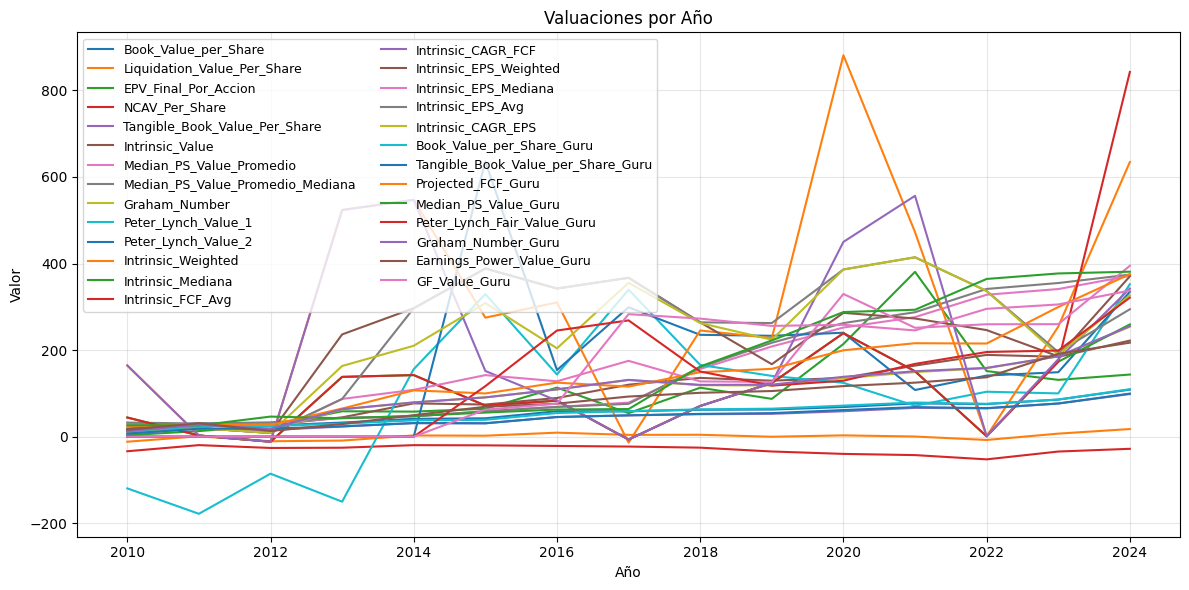

In [131]:

# Asegurar orden por Año
df_plot = df_valuaciones.sort_values("Año")

plt.figure(figsize=(12, 6))

for col in df_plot.columns[1:]:
    plt.plot(df_plot["Año"], df_plot[col], label=col)

plt.xlabel("Año")
plt.ylabel("Valor")
plt.title("Valuaciones por Año")
plt.legend(ncol=2, fontsize=9)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



## Modelo de Targets

In [132]:
data_stock_modelo = pd.read_csv(archivo_stock + '.csv')
data_stock_modelo.drop(columns=["Vol.","% var.","Cierre","Apertura"],axis=1, inplace=True)
data_stock_modelo["Fecha"] = pd.to_datetime(
    data_stock_modelo["Fecha"],
    format="%d.%m.%Y"
)

In [133]:
prices = data_stock_modelo.copy()

prices["Fecha"] = pd.to_datetime(prices["Fecha"])

prices = prices.sort_values("Fecha").reset_index(drop=True)

prices.head()

,Fecha,Máximo,Mínimo
0,2001-01-07,7.30,6.92
1,2001-01-14,7.12,6.82
2,2001-01-21,6.92,6.43
3,2001-01-28,8.40,6.92
4,2001-02-04,8.40,7.81


In [134]:
prices

,Fecha,Máximo,Mínimo
0,2001-01-07,7.30,6.92
1,2001-01-14,7.12,6.82
2,2001-01-21,6.92,6.43
3,2001-01-28,8.40,6.92
4,2001-02-04,8.40,7.81
...,...,...,...
1298,2025-12-14,317.45,306.99
1299,2025-12-21,318.59,305.42
1300,2025-12-28,315.46,308.03
1301,2026-01-04,314.00,304.00


In [135]:
mes_map = {
    "Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4,
    "May": 5, "Jun": 6, "Jul": 7, "Aug": 8,
    "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12
}

headers_df = pd.DataFrame({
    "Header": valid_headers
})

headers_df["Mes"] = headers_df["Header"].str[:3].map(mes_map)
headers_df["Año"] = headers_df["Header"].str[-4:].astype(int)

# Fecha base = primer día del mes del header
headers_df["Fecha_base"] = pd.to_datetime(
    headers_df["Año"].astype(str) + "-" +
    headers_df["Mes"].astype(str).str.zfill(2) + "-01"
)

headers_df["Fecha_teorica"] = headers_df["Fecha_base"] + pd.DateOffset(months=1)

valuations = df_valuaciones.copy()

valuations = valuations.merge(
    headers_df[["Año", "Fecha_teorica"]],
    on="Año",
    how="left"
)

In [136]:
price_dates = prices[["Fecha"]]

valuations = pd.merge_asof(
    valuations.sort_values("Fecha_teorica"),
    price_dates.sort_values("Fecha"),
    left_on="Fecha_teorica",
    right_on="Fecha",
    direction="forward"
)

valuations = valuations.rename(columns={"Fecha": "Fecha_base"})

valuations[["Año", "Fecha_teorica", "Fecha_base"]].head()


,Año,Fecha_teorica,Fecha_base
0,2010,2011-01-01,2011-01-02
1,2011,2012-01-01,2012-01-01
2,2012,2013-01-01,2013-01-06
3,2013,2014-01-01,2014-01-05
4,2014,2015-01-01,2015-01-04


In [137]:
id_cols = ["Año", "Fecha_base"]

# Asegúrate de no tener columnas duplicadas
valuations = valuations.loc[:, ~valuations.columns.duplicated()].copy()

# Seleccionar SOLO columnas de métodos (numéricas) y excluir id_cols
method_cols = [
    c for c in valuations.columns
    if c not in id_cols and pd.api.types.is_numeric_dtype(valuations[c])
]

valuations_long = valuations.melt(
    id_vars=id_cols,
    value_vars=method_cols,
    var_name="Metodo",
    value_name="Valor"
)

# Forzar a numérico y limpiar
valuations_long["Valor"] = pd.to_numeric(valuations_long["Valor"], errors="coerce")
valuations_long = valuations_long.dropna(subset=["Valor"])


In [138]:
valuations_long

,Año,Fecha_base,Metodo,Valor
0,2010,2011-01-02,Book_Value_per_Share,18.931922
1,2011,2012-01-01,Book_Value_per_Share,31.091709
2,2012,2013-01-06,Book_Value_per_Share,25.710466
3,2013,2014-01-05,Book_Value_per_Share,32.608505
4,2014,2015-01-04,Book_Value_per_Share,41.188855
...,...,...,...,...
400,2020,2021-01-03,GF_Value_Guru,258.450000
401,2021,2022-01-02,GF_Value_Guru,245.500000
402,2022,2023-01-01,GF_Value_Guru,295.370000
403,2023,2024-01-07,GF_Value_Guru,305.450000


In [139]:
df_anual_filtrado

,Fiscal Period,Dec2005,Dec2006,Dec2007,Dec2008,Dec2009,Dec2010,Dec2011,Dec2012,Dec2013,...,Dec2015,Dec2016,Dec2017,Dec2018,Dec2019,Dec2020,Dec2021,Dec2022,Dec2023,Dec2024
0,Revenue per Share,60.081,62.346,73.760,77.344,88.057,82.413,85.112,88.377,110.833,...,133.111,155.944,159.249,176.278,186.760,225.925,247.529,293.863,305.651,360.600
1,EBITDA per Share,6.023,6.070,6.287,-15.799,11.017,7.854,15.654,7.441,14.300,...,21.139,25.695,24.497,27.428,30.750,34.345,35.750,37.984,40.522,59.568
2,EBIT per Share,3.522,3.625,3.859,-18.234,8.142,5.175,13.089,4.710,10.753,...,17.488,21.354,19.965,21.922,23.077,25.185,26.148,27.663,30.109,46.179
3,Earnings per Share (Diluted),2.660,3.254,4.601,-21.301,2.664,0.774,9.251,2.004,7.150,...,1.740,13.535,14.031,11.831,11.670,13.313,16.113,16.673,19.944,29.582
4,EPS without NRI,2.545,3.709,2.612,-3.230,2.354,1.023,1.811,0.783,7.511,...,11.849,11.683,15.511,12.096,11.798,13.827,14.878,17.019,19.990,29.116
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
252,Profitability Rank,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,6.000,7.000,6.000,6.000,6.000,8.000,8.000,9.000,8.000,9.000
253,GF Value Rank,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,1.000,0.000,4.000,10.000,8.000,8.000,9.000,9.000,5.000,7.000
254,Growth Rank,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,8.000,0.000,7.000,7.000,7.000,10.000,4.000,4.000,5.000,9.000
255,Momentum Rank,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,6.000,0.000,7.000,8.000,7.000,8.000,7.000,7.000,9.000,7.000


In [140]:
valuations_long

,Año,Fecha_base,Metodo,Valor
0,2010,2011-01-02,Book_Value_per_Share,18.931922
1,2011,2012-01-01,Book_Value_per_Share,31.091709
2,2012,2013-01-06,Book_Value_per_Share,25.710466
3,2013,2014-01-05,Book_Value_per_Share,32.608505
4,2014,2015-01-04,Book_Value_per_Share,41.188855
...,...,...,...,...
400,2020,2021-01-03,GF_Value_Guru,258.450000
401,2021,2022-01-02,GF_Value_Guru,245.500000
402,2022,2023-01-01,GF_Value_Guru,295.370000
403,2023,2024-01-07,GF_Value_Guru,305.450000


In [141]:
# valuations_long.to_excel('valuaciones_long_format.xlsx', index=False)

In [142]:
tol = 0.05
H = 156

# Asegurar datetime y orden
prices["Fecha"] = pd.to_datetime(prices["Fecha"])
prices = prices.sort_values("Fecha").reset_index(drop=True)

# Ajusta estos nombres si tus columnas se llaman distinto
HIGH_COL = "Máximo"
LOW_COL  = "Mínimo"

# Chequeos rápidos
assert prices["Fecha"].is_monotonic_increasing
assert {HIGH_COL, LOW_COL}.issubset(prices.columns)
assert {"Fecha_base", "Metodo", "Valor"}.issubset(valuations_long.columns)

In [143]:
valuations_long["L"] = valuations_long["Valor"] * (1 - tol)
valuations_long["U"] = valuations_long["Valor"] * (1 + tol)


In [144]:
valuations_long["Fecha_fin"] = valuations_long["Fecha_base"] + pd.to_timedelta(H, unit="W")


In [145]:
def first_hit(fecha_base, fecha_fin, valor, L, U):
    if valor is None or pd.isna(valor) or valor <= 0:
        return np.nan, np.nan, pd.NaT, pd.NA

    w = prices.loc[
        (prices["Fecha"] >= fecha_base) & (prices["Fecha"] <= fecha_fin),
        ["Fecha", HIGH_COL, LOW_COL]
    ]

    if w.empty:
        return False, np.nan, pd.NaT, pd.NA

    base_high = w.iloc[0][HIGH_COL]
    base_low  = w.iloc[0][LOW_COL]
    p_base = (base_high + base_low) / 2

    if p_base < L:
        side = "long"
    elif p_base > U:
        side = "short"
    else:
        side = "at_target"  

    hit_mask = (w[LOW_COL] <= U) & (w[HIGH_COL] >= L)
    if not hit_mask.any():
        return False, np.nan, pd.NaT, side

    first_pos = int(np.argmax(hit_mask.to_numpy()))
    hit_date = w.iloc[first_pos]["Fecha"]
    tth_weeks = first_pos

    return True, tth_weeks, hit_date, side


In [146]:
hits = valuations_long.apply(
    lambda r: first_hit(r["Fecha_base"], r["Fecha_fin"], r["Valor"], r["L"], r["U"]),
    axis=1,
    result_type="expand"
)

hits.columns = ["hit", "tth_weeks", "hit_date", "side"]
valuations_long[["hit", "tth_weeks", "hit_date", "side"]] = hits


In [147]:
valuations_long

,Año,Fecha_base,Metodo,Valor,L,U,Fecha_fin,hit,tth_weeks,hit_date,side
0,2010,2011-01-02,Book_Value_per_Share,18.931922,17.985326,19.878519,2013-12-29,True,19.0,2011-05-15,short
1,2011,2012-01-01,Book_Value_per_Share,31.091709,29.537124,32.646295,2014-12-28,True,4.0,2012-01-29,long
2,2012,2013-01-06,Book_Value_per_Share,25.710466,24.424943,26.995990,2016-01-03,False,NaN,NaT,short
3,2013,2014-01-05,Book_Value_per_Share,32.608505,30.978080,34.238931,2017-01-01,False,NaN,NaT,short
4,2014,2015-01-04,Book_Value_per_Share,41.188855,39.129413,43.248298,2017-12-31,False,NaN,NaT,short
...,...,...,...,...,...,...,...,...,...,...,...
400,2020,2021-01-03,GF_Value_Guru,258.450000,245.527500,271.372500,2023-12-31,True,12.0,2021-03-28,long
401,2021,2022-01-02,GF_Value_Guru,245.500000,233.225000,257.775000,2024-12-29,True,0.0,2022-01-02,short
402,2022,2023-01-01,GF_Value_Guru,295.370000,280.601500,310.138500,2025-12-28,True,1.0,2023-01-08,long
403,2023,2024-01-07,GF_Value_Guru,305.450000,290.177500,320.722500,2027-01-03,True,0.0,2024-01-07,at_target


In [148]:
valuations_long[["Año","Metodo","Valor","Fecha_base","hit","tth_weeks","hit_date"]]

# Convertir NaT -> NaN en hit (y cualquier cosa rara)
valuations_long["hit"] = valuations_long["hit"].replace({pd.NaT: np.nan})

# Fuerza dtype booleano nullable (permite True/False/<NA>)
valuations_long["hit"] = valuations_long["hit"].astype("boolean")


In [149]:
summary = (
    valuations_long
    .groupby("Metodo", as_index=False)
    .agg(
        targets=("hit", "count"),       
        hits=("hit", "sum"),              
        hit_rate=("hit", "mean"),        
        median_tth=("tth_weeks", "median"),
        avg_tth=("tth_weeks", "mean"),
    )
)

for years, weeks in [(1, 52), (2, 104), (3, 156)]:
    col = f"hit_le_{years}y"

    tmp = valuations_long["hit"] & (valuations_long["tth_weeks"] <= weeks)

    summary[col] = (
        valuations_long
        .assign(_tmp=tmp)
        .groupby("Metodo")["_tmp"]
        .mean()            
        .values
    )

summary = summary.sort_values(
    ["hit_rate", "median_tth"],
    ascending=[False, True]
).reset_index(drop=True)


In [150]:
metodos_top = summary.loc[summary["hit_rate"] >= 0.60, "Metodo"]

df_hits_por_anio = (
    valuations_long
    .loc[
        valuations_long["Metodo"].isin(metodos_top),
        ["Año", "Metodo", "Valor", "hit", "tth_weeks", "hit_date","side"]
    ]
    .sort_values(["Metodo", "Año"])
    .reset_index(drop=True)
)

df_hits_por_anio

,Año,Metodo,Valor,hit,tth_weeks,hit_date,side
0,2010,GF_Value_Guru,0.000000,<NA>,NaN,NaT,<NA>
1,2011,GF_Value_Guru,0.000000,<NA>,NaN,NaT,<NA>
2,2012,GF_Value_Guru,0.000000,<NA>,NaN,NaT,<NA>
3,2013,GF_Value_Guru,0.000000,<NA>,NaN,NaT,<NA>
4,2014,GF_Value_Guru,0.000000,<NA>,NaN,NaT,<NA>
5,2015,GF_Value_Guru,62.370000,False,NaN,NaT,short
6,2016,GF_Value_Guru,76.230000,False,NaN,NaT,short
7,2017,GF_Value_Guru,283.070000,True,133.0,2020-07-26,long
8,2018,GF_Value_Guru,272.750000,True,80.0,2020-07-19,long
9,2019,GF_Value_Guru,255.950000,True,17.0,2020-05-03,long


In [151]:
df_hits_por_anio

,Año,Metodo,Valor,hit,tth_weeks,hit_date,side
0,2010,GF_Value_Guru,0.000000,<NA>,NaN,NaT,<NA>
1,2011,GF_Value_Guru,0.000000,<NA>,NaN,NaT,<NA>
2,2012,GF_Value_Guru,0.000000,<NA>,NaN,NaT,<NA>
3,2013,GF_Value_Guru,0.000000,<NA>,NaN,NaT,<NA>
4,2014,GF_Value_Guru,0.000000,<NA>,NaN,NaT,<NA>
5,2015,GF_Value_Guru,62.370000,False,NaN,NaT,short
6,2016,GF_Value_Guru,76.230000,False,NaN,NaT,short
7,2017,GF_Value_Guru,283.070000,True,133.0,2020-07-26,long
8,2018,GF_Value_Guru,272.750000,True,80.0,2020-07-19,long
9,2019,GF_Value_Guru,255.950000,True,17.0,2020-05-03,long


In [152]:
df_hits_por_anio.to_excel('valuaciones_hits_por_anio_GRUMAB.xlsx', index=False)

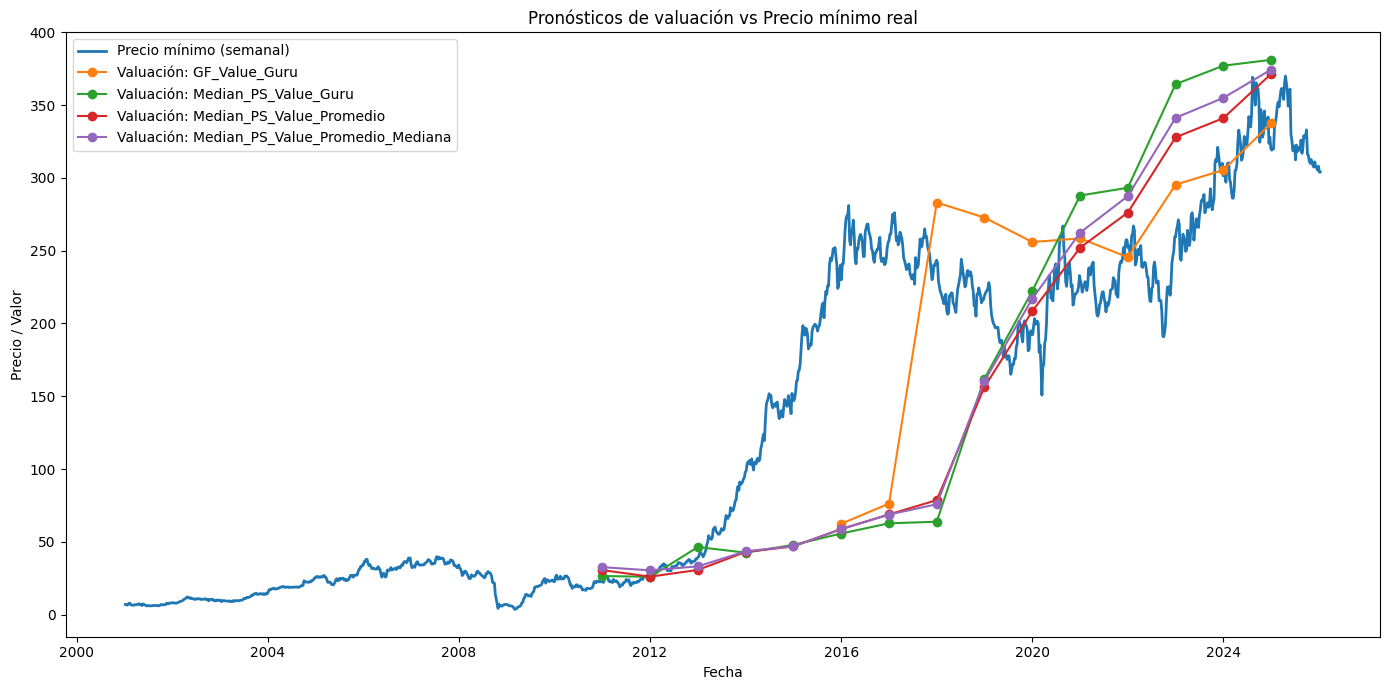

In [153]:
prices = prices.copy()
prices["Fecha"] = pd.to_datetime(prices["Fecha"], errors="coerce")
prices = prices.dropna(subset=["Fecha"]).sort_values("Fecha")

df_hits = df_hits_por_anio.copy()
df_hits["Año"] = df_hits["Año"].astype(int)
df_hits["Valor"] = pd.to_numeric(df_hits["Valor"], errors="coerce")


mes_map = {
    "Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4,
    "May": 5, "Jun": 6, "Jul": 7, "Aug": 8,
    "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12
}

headers_df = pd.DataFrame({"Header": valid_headers})
headers_df["Mes"] = headers_df["Header"].str[:3].map(mes_map)
headers_df["Año"] = headers_df["Header"].str[-4:].astype(int)

headers_df["Fecha_base"] = pd.to_datetime(
    headers_df["Año"].astype(str) + "-" +
    headers_df["Mes"].astype(str).str.zfill(2) + "-01",
    errors="coerce"
)
headers_df["Fecha_teorica"] = headers_df["Fecha_base"] + pd.DateOffset(months=1)

df_hits = df_hits.merge(
    headers_df[["Año", "Fecha_teorica"]],
    on="Año",
    how="left"
)

df_hits["Fecha_teorica"] = df_hits["Fecha_teorica"].fillna(
    pd.to_datetime((df_hits["Año"] + 1).astype(str) + "-01-01")
)


metodos_plot = (
    df_hits[df_hits["Valor"] > 0]
    .groupby("Metodo")["Valor"]
    .count()
    .sort_values(ascending=False)        
    .index
)

df_hits_plot = df_hits[df_hits["Metodo"].isin(metodos_plot)].copy()


plt.figure(figsize=(14, 7))

plt.plot(
    prices["Fecha"],
    prices["Mínimo"],
    label="Precio mínimo (semanal)",
    linewidth=2
)

for metodo, g in df_hits_plot.groupby("Metodo"):
    g = (
        g.dropna(subset=["Fecha_teorica", "Valor"])
         .sort_values("Fecha_teorica")
    )
    g = g[g["Valor"] > 0]  
    plt.plot(
        g["Fecha_teorica"],
        g["Valor"],
        marker="o",
        linewidth=1.5,
        label=f"Valuación: {metodo}"
    )

plt.title("Pronósticos de valuación vs Precio mínimo real")
plt.xlabel("Fecha")
plt.ylabel("Precio / Valor")
plt.legend()
plt.tight_layout()
plt.show()
